<a href="https://colab.research.google.com/github/sheramir/MIT-DS/blob/main/Shinkansen_Travel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Shinkansen Travel Experience**

**The goal of the problem:** Predict whether a passenger was satisfied or not considering his/her overall experience of traveling on the Shinkansen Bullet Train.</br>

This problem statement is based on the Shinkansen Bullet Train in Japan, and passengers’ experience with that mode of travel. This machine-learning exercise aims to determine the relative importance of each parameter with regard to their contribution to the passengers’ overall travel experience. The dataset contains a random sample of individuals who traveled on this train. The on-time performance of the trains along with passenger information is published in a file named ‘Traveldata_train.csv’.  These passengers were later asked to provide their feedback on various parameters related to the travel along with their overall experience. These collected details are made available in the survey report labeled ‘Surveydata_train.csv’.</br>

In the survey, each passenger was explicitly asked whether they were satisfied with their overall travel experience or not, and that is captured in the data of the survey report under the variable labeled ‘Overall_Experience’. </br>

The objective of this problem is to understand which parameters play an important role in swaying passenger feedback towards a positive scale. You are provided test data containing the travel data and the survey data of passengers. Both the test data and the train data are collected at the same time and belong to the same population.

In [2]:
#!pip install --upgrade --force-reinstall catboost

#!pip install --upgrade catboost

#!pip install catboost


Found existing installation: numpy 1.23.5
Uninstalling numpy-1.23.5:
  Successfully uninstalled numpy-1.23.5
  Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.3 kB)
Using cached numpy-1.23.5-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.1 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray 2025.1.2 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
chex 0.1.89 requires numpy>=1.24.1, but you have numpy 1.23.5 which is incompatible.
pymc 5.21.1 requires numpy>=1.25.0, but you have numpy 1.23.5 which is incompatible.
imbalanced-learn 0.13.0 requires numpy<3,>=1.24.3, but you have numpy 1.23.5 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you have numpy 1.23.5 which is incompatible.
bigframes 1.40.0 requires numpy>=1.24.0, but you have numpy 1.23.5 which is

  Using cached catboost-1.2.7-cp311-cp311-manylinux2014_x86_64.whl.metadata (1.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 10.9 MB/s eta 0:00:00


In [3]:
!pip uninstall -y numpy catboost seaborn

!pip install --upgrade numpy

!pip install seaborn

!pip install --no-cache-dir --no-deps catboost

Found existing installation: numpy 2.2.4
Uninstalling numpy-2.2.4:
  Successfully uninstalled numpy-2.2.4
Found existing installation: catboost 1.2.7
Uninstalling catboost-1.2.7:
  Successfully uninstalled catboost-1.2.7
Found existing installation: seaborn 0.13.2
Uninstalling seaborn-0.13.2:
  Successfully uninstalled seaborn-0.13.2
  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
missingno 0.5.2 requires seaborn, which is not installed.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
  Using cached seaborn-0.13.2-py3-none-any.whl.me

In [5]:
!pip install --upgrade --force-reinstall numpy
!pip install --upgrade --force-reinstall catboost

  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.4
    Uninstalling numpy-2.2.4:
      Successfully uninstalled numpy-2.2.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
catboost 1.2.7 requires numpy<2.0,>=1.16.0, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
  Using cached catboost-1.2.7-cp311-cp311-manylinux2014_x86_64.whl.metadata (1.2 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
! pip show catboost

Name: catboost
Version: 1.2.7
Summary: CatBoost Python Package
Home-page: https://catboost.ai
Author: CatBoost Developers
Author-email: 
License: Apache License, Version 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: graphviz, matplotlib, numpy, pandas, plotly, scipy, six
Required-by: 


In [1]:
# Import common libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Machine learning models

from sklearn import tree

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier


import catboost

from catboost import CatBoostClassifier

# Metrics to evaluate the model
from sklearn import metrics

from sklearn.metrics import confusion_matrix, classification_report,recall_score,precision_score, accuracy_score

# For tuning the model
from sklearn.model_selection import GridSearchCV, cross_val_score


In [3]:

print("NumPy version:", np.__version__)
print("CatBoost version:", catboost.__version__)

NumPy version: 1.26.4
CatBoost version: 1.2.7


In [4]:
# Model optimization

try:
  import optuna
except ImportError:
  !pip install optuna
  import optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 5.6 MB/s eta 0:00:00


In [5]:
# File handling

import os
from zipfile import ZipFile

# To ignore warnings
import warnings
warnings.filterwarnings("ignore")

### **Read Data**
 **REPLACE KAGGLE DATA WITH PROBLEM DATA!!!**

In [6]:
zip_file = '/content/drive/MyDrive/ADSP/Hackathon/Shinkansen_Hackathon.zip'
Data_Folder = '/content/Shinkansen_Hackathon/Data'

# Check if Data_Folder exists. Extract zip file if not

if not os.path.exists(Data_Folder):
  with ZipFile(zip_file, 'r') as zip:
    zip.extractall()
    print('Done Unzip')
else:
  print('Data Folder Exists. No unzipping needed')

# Read csv into dataframes
Travel_train_df = pd.read_csv(Data_Folder + '/Traveldata_train.csv')
Travel_test_df = pd.read_csv(Data_Folder + '/Traveldata_test.csv')
Survey_train_df = pd.read_csv(Data_Folder + '/Surveydata_train.csv')
Survey_test_df = pd.read_csv(Data_Folder + '/Surveydata_test.csv')
sample_submission_df = pd.read_csv(Data_Folder + '/Sample_Submission.csv')


Done Unzip


In [7]:
Travel_train_df.sort_values(by=['ID']).head()

,ID,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins
0,98800001,Female,Loyal Customer,52.0,NaN,Business,272,0.0,5.0
1,98800002,Male,Loyal Customer,48.0,Personal Travel,Eco,2200,9.0,0.0
2,98800003,Female,Loyal Customer,43.0,Business Travel,Business,1061,77.0,119.0
3,98800004,Female,Loyal Customer,44.0,Business Travel,Business,780,13.0,18.0
4,98800005,Female,Loyal Customer,50.0,Business Travel,Business,1981,0.0,0.0


In [8]:
# Show survey_train.df.head() sorted by ID
Survey_train_df.sort_values(by=['ID']).head()

,ID,Overall_Experience,Seat_Comfort,Seat_Class,Arrival_Time_Convenient,Catering,Platform_Location,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,Onboard_Service,Legroom,Baggage_Handling,CheckIn_Service,Cleanliness,Online_Boarding
0,98800001,0,Needs Improvement,Green Car,Excellent,Excellent,Very Convenient,Good,Needs Improvement,Acceptable,Needs Improvement,Needs Improvement,Acceptable,Needs Improvement,Good,Needs Improvement,Poor
1,98800002,0,Poor,Ordinary,Excellent,Poor,Needs Improvement,Good,Poor,Good,Good,Excellent,Needs Improvement,Poor,Needs Improvement,Good,Good
2,98800003,1,Needs Improvement,Green Car,Needs Improvement,Needs Improvement,Needs Improvement,Needs Improvement,Good,Excellent,Excellent,Excellent,Excellent,Excellent,Good,Excellent,Excellent
3,98800004,0,Acceptable,Ordinary,Needs Improvement,NaN,Needs Improvement,Acceptable,Needs Improvement,Acceptable,Acceptable,Acceptable,Acceptable,Acceptable,Good,Acceptable,Acceptable
4,98800005,1,Acceptable,Ordinary,Acceptable,Acceptable,Manageable,Needs Improvement,Good,Excellent,Good,Good,Good,Good,Good,Good,Good


## **Examine the Data**

In [9]:
# Merge Travel data with Survey data by "ID"
Merged_train_df = Travel_train_df.merge(Survey_train_df, on='ID', how='left')
Merged_test_df = Travel_test_df.merge(Survey_test_df, on='ID', how='left')

In [10]:
# Examine the train data
Merged_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94379 entries, 0 to 94378
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       94379 non-null  int64  
 1   Gender                   94302 non-null  object 
 2   Customer_Type            85428 non-null  object 
 3   Age                      94346 non-null  float64
 4   Type_Travel              85153 non-null  object 
 5   Travel_Class             94379 non-null  object 
 6   Travel_Distance          94379 non-null  int64  
 7   Departure_Delay_in_Mins  94322 non-null  float64
 8   Arrival_Delay_in_Mins    94022 non-null  float64
 9   Overall_Experience       94379 non-null  int64  
 10  Seat_Comfort             94318 non-null  object 
 11  Seat_Class               94379 non-null  object 
 12  Arrival_Time_Convenient  85449 non-null  object 
 13  Catering                 85638 non-null  object 
 14  Platform_Location     

In [11]:
# Examine the test data
Merged_test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35602 entries, 0 to 35601
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       35602 non-null  int64  
 1   Gender                   35572 non-null  object 
 2   Customer_Type            32219 non-null  object 
 3   Age                      35591 non-null  float64
 4   Type_Travel              32154 non-null  object 
 5   Travel_Class             35602 non-null  object 
 6   Travel_Distance          35602 non-null  int64  
 7   Departure_Delay_in_Mins  35573 non-null  float64
 8   Arrival_Delay_in_Mins    35479 non-null  float64
 9   Seat_Comfort             35580 non-null  object 
 10  Seat_Class               35602 non-null  object 
 11  Arrival_Time_Convenient  32277 non-null  object 
 12  Catering                 32245 non-null  object 
 13  Platform_Location        35590 non-null  object 
 14  Onboard_Wifi_Service  

In [12]:
# Remove 'ID' from dataframe
ID_train_df = Merged_train_df.pop('ID')
ID_test_df = Merged_test_df.pop('ID')


In [13]:
# Check numerical columns statistics
Merged_train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,94346.0,39.419647,15.116632,7.0,27.0,40.0,51.0,85.0
Travel_Distance,94379.0,1978.888185,1027.961019,50.0,1359.0,1923.0,2538.0,6951.0
Departure_Delay_in_Mins,94322.0,14.647092,38.138781,0.0,0.0,0.0,12.0,1592.0
Arrival_Delay_in_Mins,94022.0,15.005222,38.439409,0.0,0.0,0.0,13.0,1584.0
Overall_Experience,94379.0,0.546658,0.497821,0.0,0.0,1.0,1.0,1.0


**Observation:**</br>
- We might want to create categorical age-group feature (instead of int)
- We might want to create categorical distance feature
- We might want to create categorical delay features for departure and arrival
- We should check for correlation between departure and arrival delays
- We might want to remove outliers

In [14]:
# Check for null values
Merged_train_df.isnull().sum()

,0
Gender,77
Customer_Type,8951
Age,33
Type_Travel,9226
Travel_Class,0
Travel_Distance,0
Departure_Delay_in_Mins,57
Arrival_Delay_in_Mins,357
Overall_Experience,0
Seat_Comfort,61


**Observation:**</br>
There are missing values in categorical and numerical columns

In [15]:
categorical_columns = Merged_test_df.select_dtypes(include=['object']).columns
numerical_columns = Merged_test_df.select_dtypes(exclude=['object']).columns
rating_columns = Survey_test_df.columns[1:-1]

In [16]:
# get the maximum number of unique values
def get_categories(mydf):
  max_unique = 0
  my_categorical = mydf.select_dtypes(include=['object']).columns

  for col in my_categorical:
    if len(mydf[col].unique()) > max_unique:
      max_unique = len(mydf[col].unique())

  # create a dataframe of unique values of all categorical.
  categorical_unique_values_df = pd.DataFrame(columns=my_categorical)
  for col in my_categorical:
    cat_unique = mydf[col].unique()  # Get all unique values for that column
    if len(cat_unique) < max_unique:  # Fill values with '-' so all columns have the same size
      cat_unique = np.append(cat_unique, ['-']*(max_unique-len(cat_unique)))
    categorical_unique_values_df[col] = cat_unique

  # Show all unique values including Nan
  return categorical_unique_values_df.T

In [17]:
train_cat = get_categories(Merged_train_df)
train_cat

,0,1,2,3,4,5,6
Gender,Female,Male,NaN,-,-,-,-
Customer_Type,Loyal Customer,Disloyal Customer,NaN,-,-,-,-
Type_Travel,NaN,Personal Travel,Business Travel,-,-,-,-
Travel_Class,Business,Eco,-,-,-,-,-
Seat_Comfort,Needs Improvement,Poor,Acceptable,Good,Excellent,Extremely Poor,NaN
Seat_Class,Green Car,Ordinary,-,-,-,-,-
Arrival_Time_Convenient,Excellent,Needs Improvement,Acceptable,NaN,Good,Poor,Extremely Poor
Catering,Excellent,Poor,Needs Improvement,NaN,Acceptable,Good,Extremely Poor
Platform_Location,Very Convenient,Needs Improvement,Manageable,Inconvenient,Convenient,NaN,Very Inconvenient
Onboard_Wifi_Service,Good,Needs Improvement,Acceptable,Excellent,Poor,Extremely Poor,NaN


In [18]:
test_cat = get_categories(Merged_test_df)
test_cat

,0,1,2,3,4,5,6
Gender,Female,Male,NaN,-,-,-,-
Customer_Type,NaN,Disloyal Customer,Loyal Customer,-,-,-,-
Type_Travel,Business Travel,Personal Travel,NaN,-,-,-,-
Travel_Class,Business,Eco,-,-,-,-,-
Seat_Comfort,Acceptable,Extremely Poor,Excellent,Poor,Needs Improvement,Good,NaN
Seat_Class,Green Car,Ordinary,-,-,-,-,-
Arrival_Time_Convenient,Acceptable,Good,Excellent,Extremely Poor,NaN,Needs Improvement,Poor
Catering,Acceptable,Poor,Excellent,Needs Improvement,Good,NaN,Extremely Poor
Platform_Location,Manageable,Very Convenient,Needs Improvement,Inconvenient,Convenient,NaN,-
Onboard_Wifi_Service,Needs Improvement,Acceptable,Excellent,Poor,Good,Extremely Poor,NaN


In [19]:
# get the maximum number of unique values
max_unique = 0
for col in categorical_columns:
  if len(Merged_train_df[col].unique()) > max_unique:
    max_unique = len(Merged_train_df[col].unique())


# create a dataframe of unique values of all categorical.
categorical_unique_values_df = pd.DataFrame(columns=categorical_columns)
for col in categorical_columns:
  cat_unique = Merged_train_df[col].unique()  # Get all unique values for that column
  if len(cat_unique) < max_unique:  # Fill values with '-' so all columns have the same size
    cat_unique = np.append(cat_unique, ['-']*(max_unique-len(cat_unique)))
  categorical_unique_values_df[col] = cat_unique


 # Show all unique values including Nan
categorical_unique_values_df.T

,0,1,2,3,4,5,6
Gender,Female,Male,NaN,-,-,-,-
Customer_Type,Loyal Customer,Disloyal Customer,NaN,-,-,-,-
Type_Travel,NaN,Personal Travel,Business Travel,-,-,-,-
Travel_Class,Business,Eco,-,-,-,-,-
Seat_Comfort,Needs Improvement,Poor,Acceptable,Good,Excellent,Extremely Poor,NaN
Seat_Class,Green Car,Ordinary,-,-,-,-,-
Arrival_Time_Convenient,Excellent,Needs Improvement,Acceptable,NaN,Good,Poor,Extremely Poor
Catering,Excellent,Poor,Needs Improvement,NaN,Acceptable,Good,Extremely Poor
Platform_Location,Very Convenient,Needs Improvement,Manageable,Inconvenient,Convenient,NaN,Very Inconvenient
Onboard_Wifi_Service,Good,Needs Improvement,Acceptable,Excellent,Poor,Extremely Poor,NaN


## **EDA - Explortory Data Analysis**

###**Univariate Analysis**

In [20]:
# Define function to draw histogram and boxplot
# We use the function to visualize different parameters without repeating the code
def draw_hist_box(data, param, value_range=None):
  '''Draw histogram and boxplot of a parameter param from data.
  value_range: Optional tuple (min, max) to define the span of values displayed.
  '''
  if param in data.columns:
    param_title = param.replace('_', ' ').title() # Format param name to use as title

    # Filter data based on value_range if provided
    if value_range:
      filtered_data = data[data[param].between(value_range[0], value_range[1])]
    else:
      filtered_data = data

    plt.figure(figsize=(8, 6))

    # Histogram
    plt.subplot(2, 1, 1) # Drawing histogram on upper subplot
    sns.histplot(data=filtered_data, x=param, kde=True)
    plt.title('Histogram of '+param_title)
    plt.xlabel("")

    # Calculate and plot mean and median of the full data
    mean_val = data[param].mean()
    median_val = data[param].median()
    plt.axvline(mean_val, color='r', linestyle='--', label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='g', linestyle='-', label=f'Median: {median_val:.2f}')
    plt.legend()  # Show legend for mean and median lines

    # Boxplot
    plt.subplot(2, 1, 2) # Drawing boxplot on lower subplot
    sns.boxplot(data=filtered_data, x=param)
    plt.title('Boxplot of '+param_title)
    plt.xlabel("")

    plt.tight_layout() # Adjusts subplot parameters for a tight layout.
    plt.show()
  else:
    print(f"Column '{param}' not found in the DataFrame.")

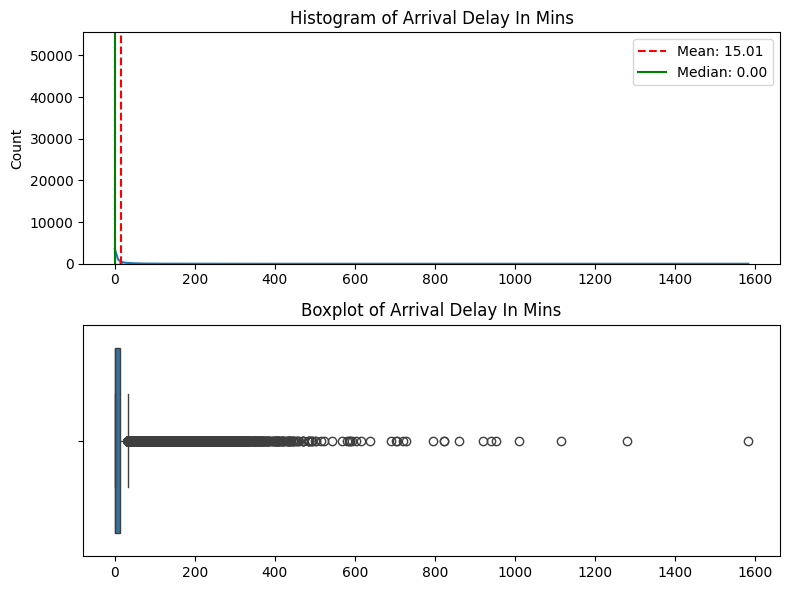

In [21]:
draw_hist_box(Merged_train_df, 'Arrival_Delay_in_Mins')

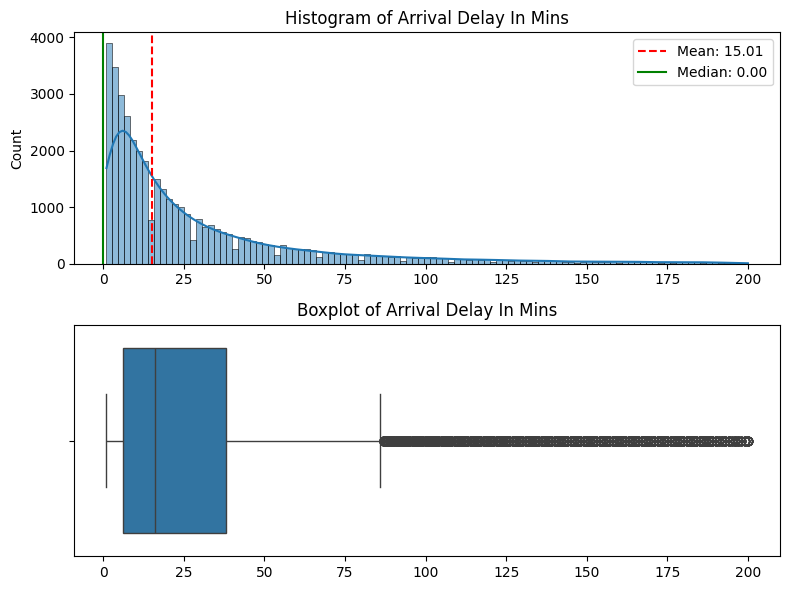

In [22]:
draw_hist_box(Merged_train_df, 'Arrival_Delay_in_Mins', (1, 200))

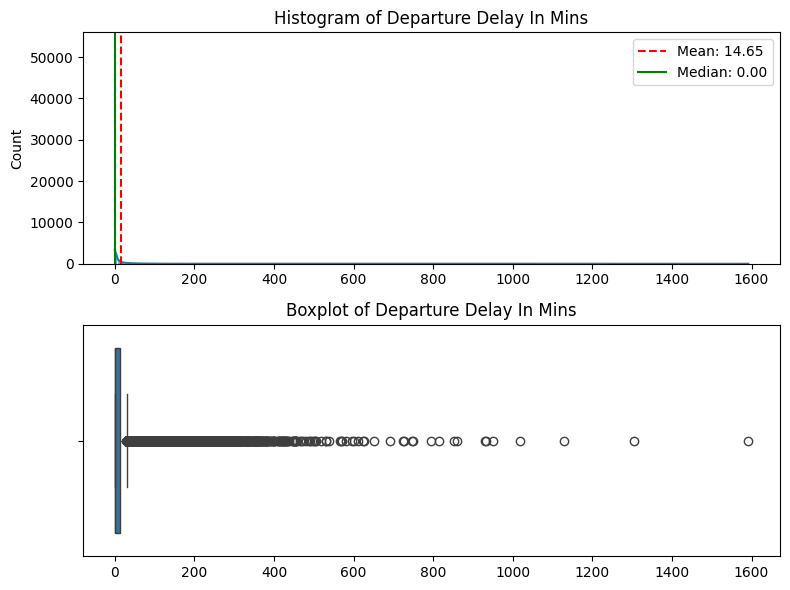

In [23]:
draw_hist_box(Merged_train_df, 'Departure_Delay_in_Mins')

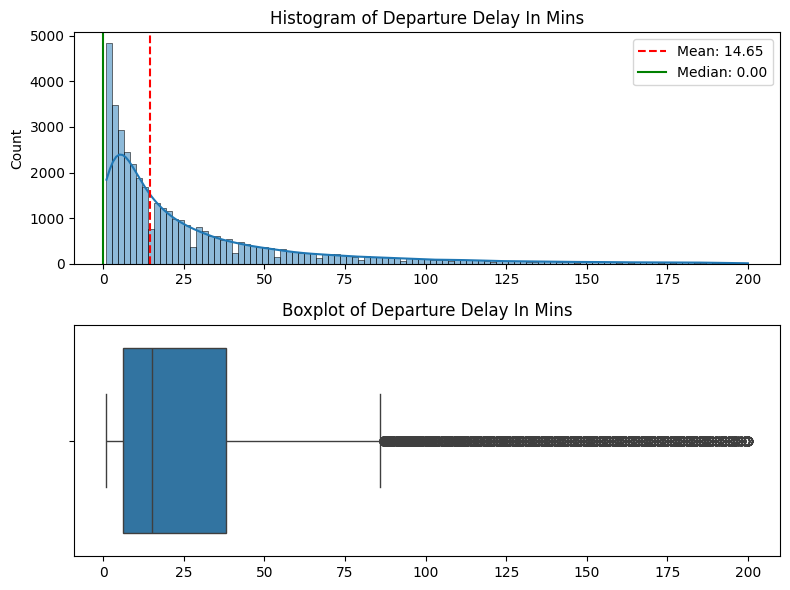

In [24]:
draw_hist_box(Merged_train_df, 'Departure_Delay_in_Mins',(1,200))

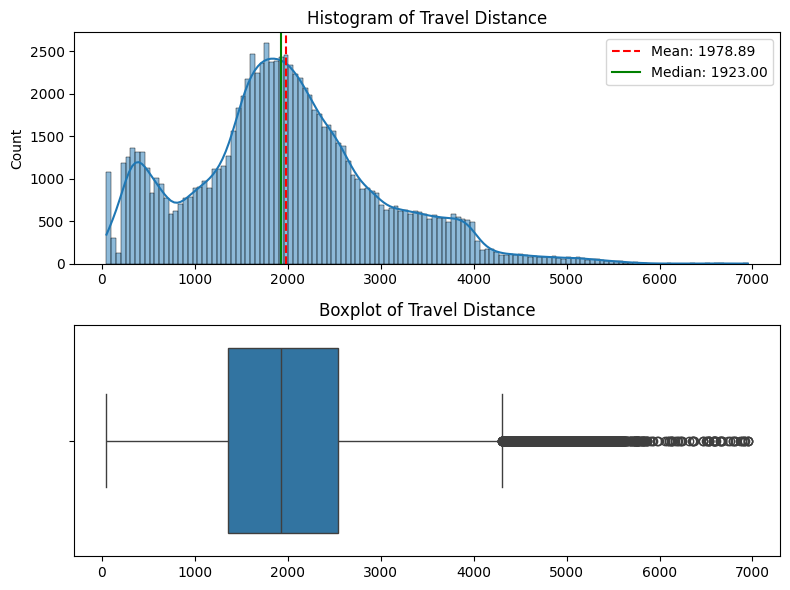

In [25]:
draw_hist_box(Merged_train_df, 'Travel_Distance')

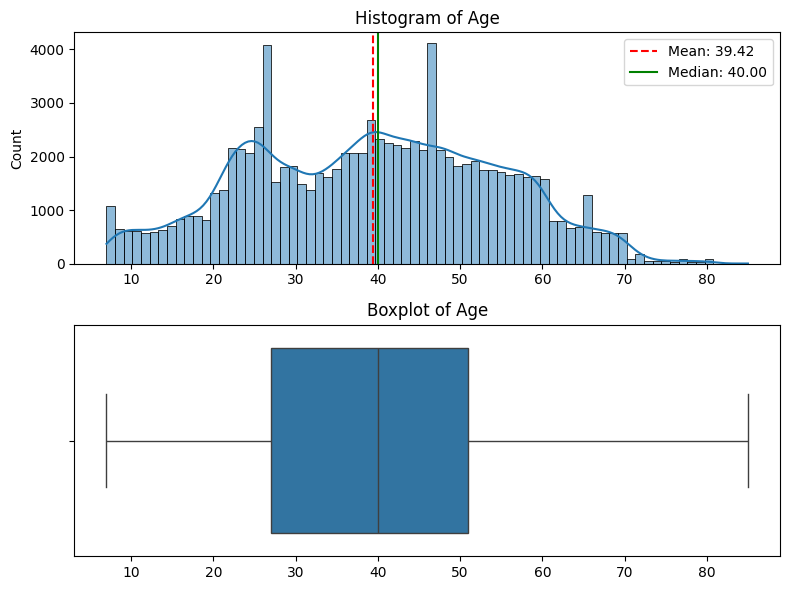

In [26]:
draw_hist_box(Merged_train_df, 'Age')

### **Observation:</br>**
- Delay values are highly skewed
- Possible solution:
  - Cap values to 100
  - Create categorical feature of no-delay, low, medium, high
  - Examine PCA to evaluate categorical values
- Don't use mean to impute missing values (use 0 or median)
- Cap travel distance to 4000, or use categorical

Overall_Experience
1    51593
0    42786
Name: count, dtype: int64


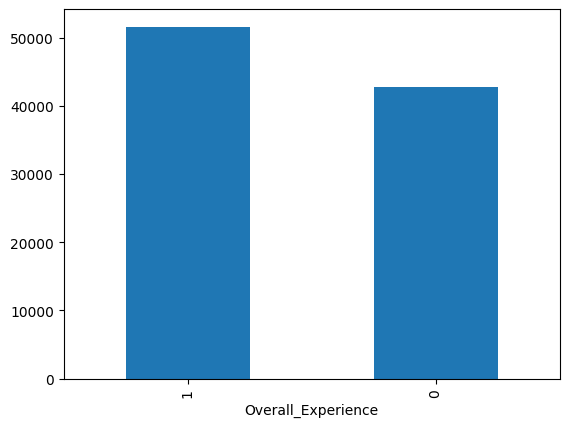

In [27]:
# Plot bar graph of output
Merged_train_df['Overall_Experience'].value_counts().plot(kind='bar')
print(Merged_train_df['Overall_Experience'].value_counts())

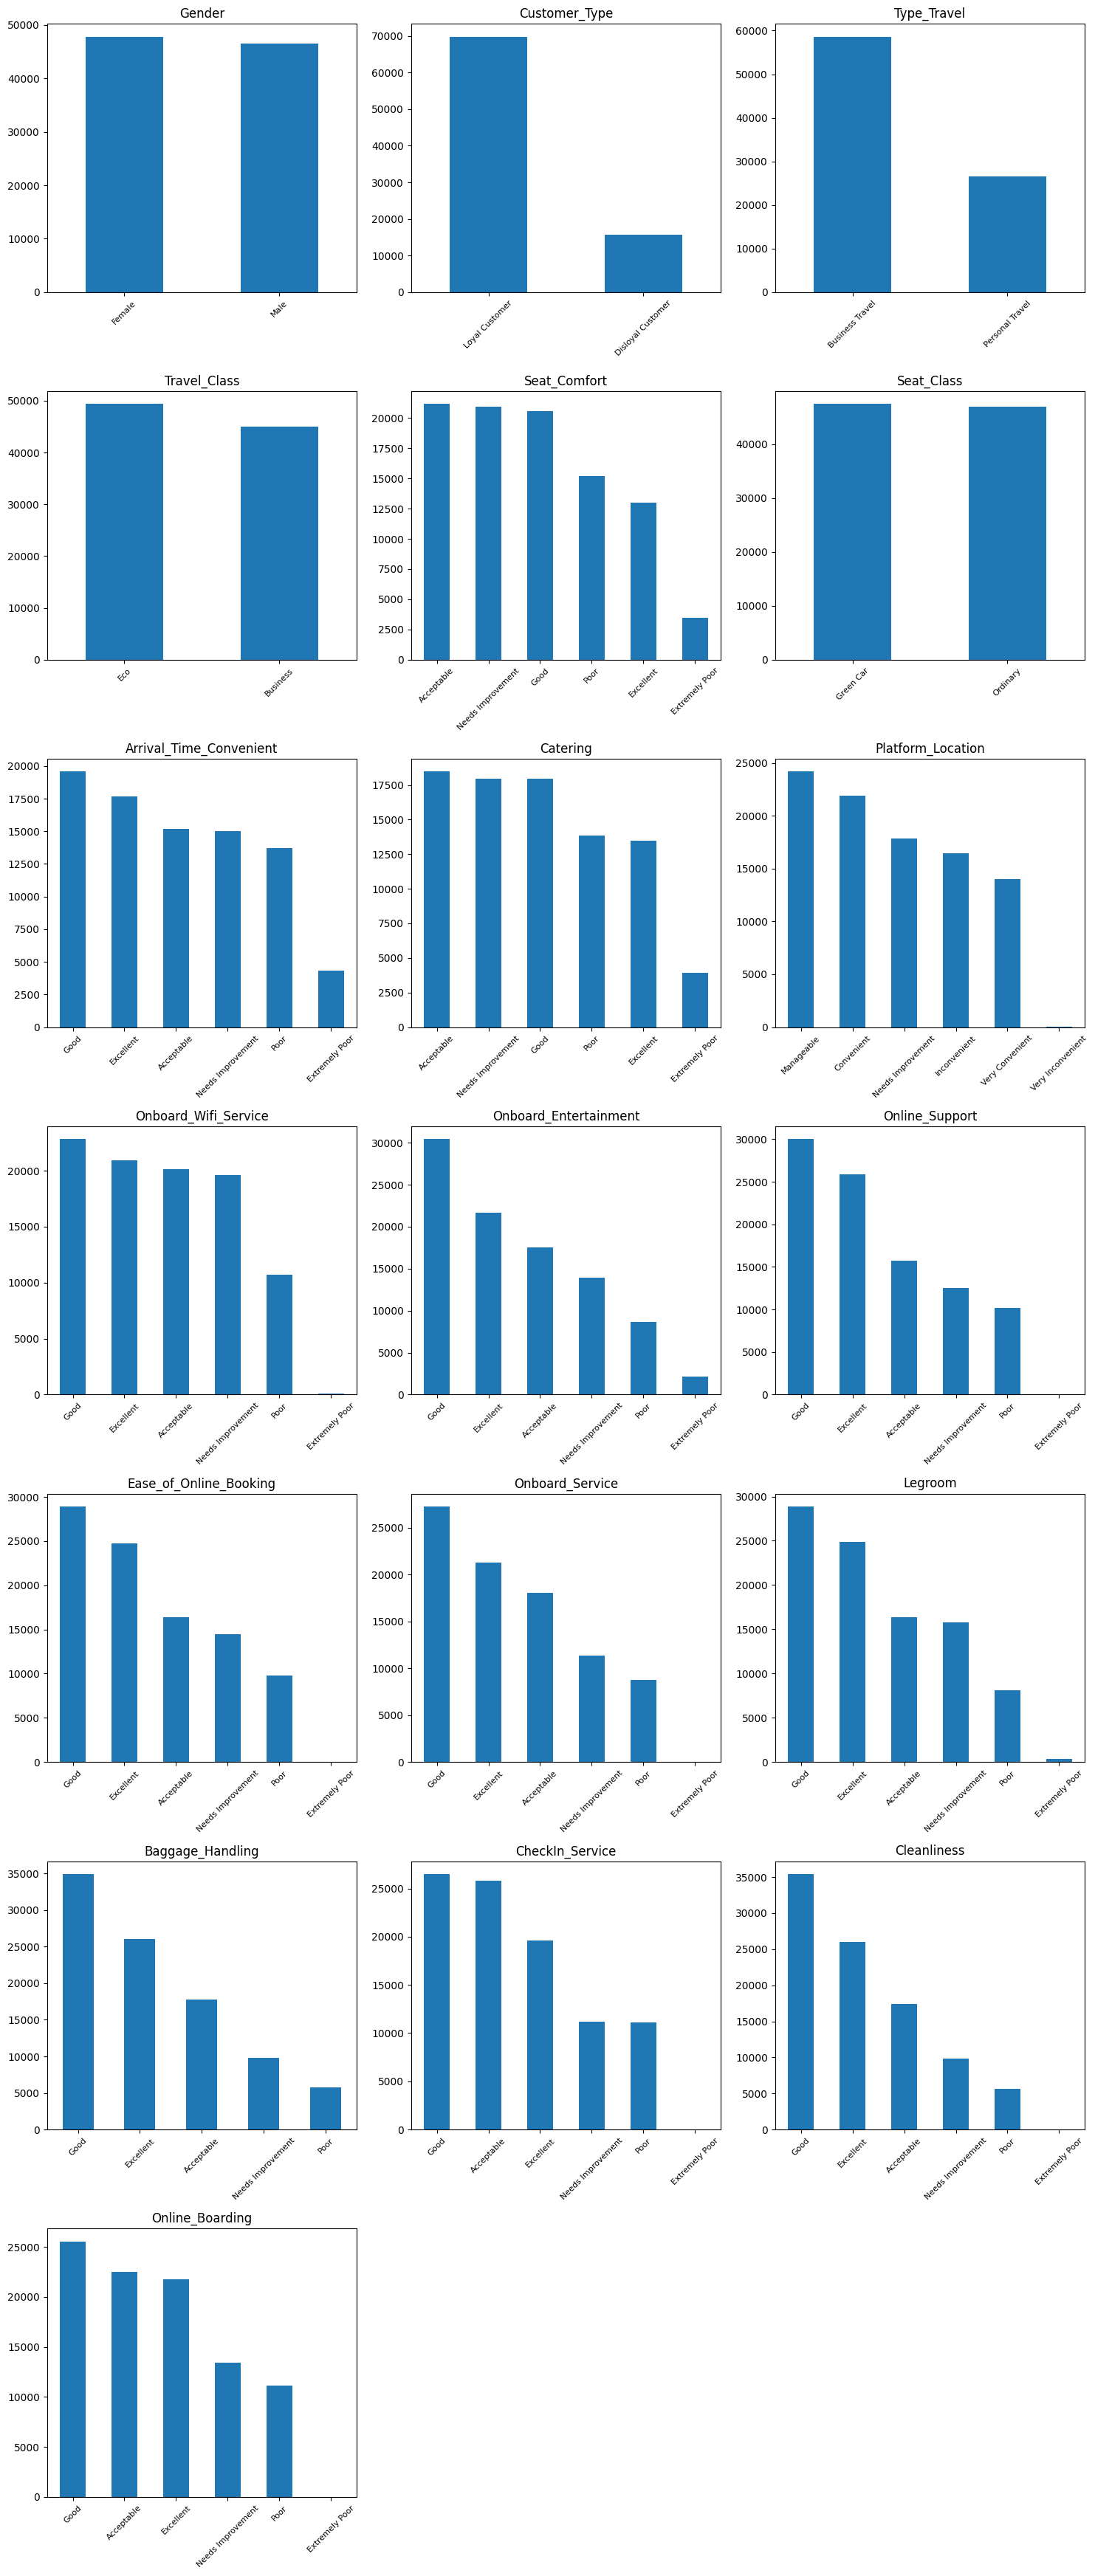

In [28]:
# prompt: Plot a 3 column matrix of bar charts of all categorical_columns

import matplotlib.pyplot as plt
import math

# Calculate the number of rows needed for the subplot grid
n_rows = math.ceil(len(categorical_columns) / 3)

# Create the subplot grid
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))

# Iterate through the categorical columns and create bar charts
for i, col in enumerate(categorical_columns):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx] if n_rows > 1 else axes[col_idx]

    Merged_train_df[col].value_counts().plot(kind='bar', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)  # Rotate x-axis labels

# Hide any unused subplots
for i in range(len(categorical_columns), n_rows * 3):
    row = i // 3
    col_idx = i % 3
    if n_rows > 1:
        axes[row, col_idx].axis('off')
    else:
      if i < 3:
        axes[col_idx].axis('off')


plt.tight_layout()
plt.show()


####**Observations:**</br>

- Most 'extremely_poor' ratings are very rare and could be combined with 'poor'.
- Only columns with enough 'extremely poor' ratings:
  - Seat_comfort
  - Catering
  - Arrival_time_convenient
  - Baggage_handling
  - Onboard_entertainment


### **Multivariate Analysis**

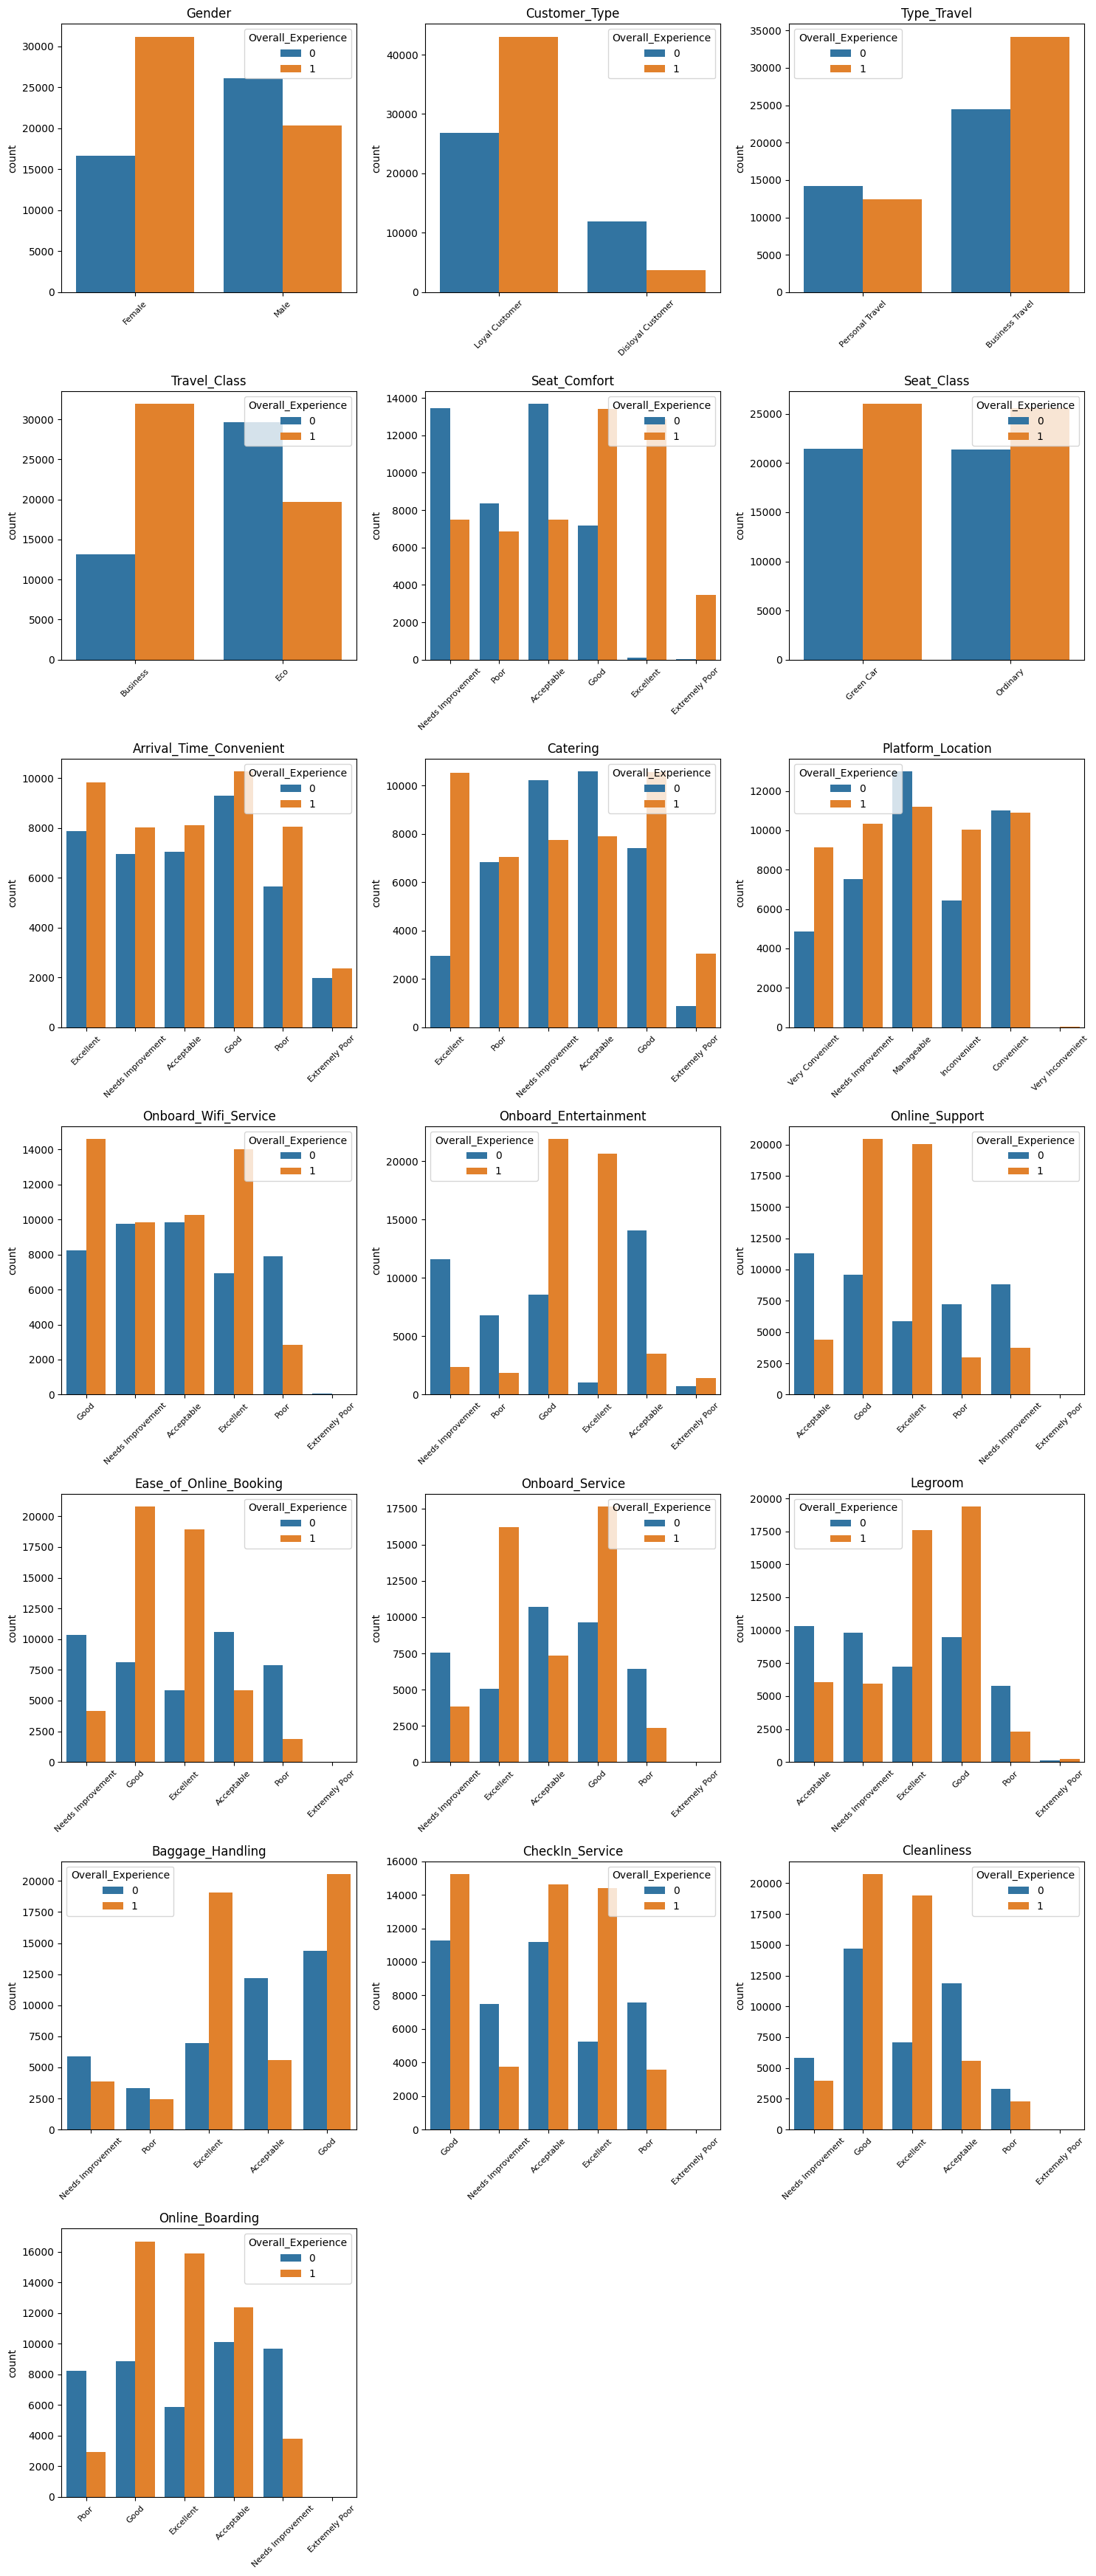

In [29]:
# prompt: Plot a 3 column matrix of bar charts of all categorical_columns. use 'Overall_Experience' as hue

import matplotlib.pyplot as plt
# Calculate the number of rows needed for the subplot grid
n_rows = math.ceil(len(categorical_columns) / 3)

# Create the subplot grid
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))

# Iterate through the categorical columns and create bar charts
for i, col in enumerate(categorical_columns):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx] if n_rows > 1 else axes[col_idx]

    sns.countplot(data=Merged_train_df, x=col, hue='Overall_Experience', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=8)  # Rotate x-axis labels

# Hide any unused subplots
for i in range(len(categorical_columns), n_rows * 3):
    row = i // 3
    col_idx = i % 3
    if n_rows > 1:
        axes[row, col_idx].axis('off')
    else:
      if i < 3:
        axes[col_idx].axis('off')

plt.tight_layout()
plt.show()


In [30]:
# # Calculate the number of rows needed for the subplot grid
# n_rows = math.ceil(len(categorical_columns) / 3)

# # Create the subplot grid
# fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))

# # Iterate through the categorical columns and create bar charts
# for i, col in enumerate(categorical_columns):
#     row = i // 3
#     col_idx = i % 3
#     ax = axes[row, col_idx] if n_rows > 1 else axes[col_idx]

#     sns.countplot(data=Merged_train_df_no_outliers, x=col, hue='Overall_Experience', ax=ax)
#     ax.set_title(col)
#     ax.set_xlabel('')
#     ax.tick_params(axis='x', rotation=45, labelsize=8)  # Rotate x-axis labels

# # Hide any unused subplots
# for i in range(len(categorical_columns), n_rows * 3):
#     row = i // 3
#     col_idx = i % 3
#     if n_rows > 1:
#         axes[row, col_idx].axis('off')
#     else:
#       if i < 3:
#         axes[col_idx].axis('off')

# plt.tight_layout()
# plt.show()


####**Observations:**</br>
- Data that affect Overall-Experience:
  - Gender
  - CustomerType
  - TypeTravel
  - Travel_Class
  - Seat_comfort
  - Catering
  - Onboardwifi_service
  - Onboard_entertainment
  - Online_support
  - Onlinebooking_Ease
  - Onboard_service
  - Leg_room
  - Baggage_handling
  - Checkin_service
  - Cleanliness
  - Online_boarding

- Data that doesn't seem to affect Overall-Experience:
  - Seat_Class
  - Arrival_time_convenient
  - Platform_location

- Most 'extremely_poor' ratings are very rare and could be combined with 'poor':
  - Platform_location (very inconvinient)
  - Onboardwifi_service
  - Online_support
  - Onlinebooking_Ease
  - Onboard_service
  - Leg_room
  - Baggage_handling (no 'extremely poor' category in training)
  - Checkin_service
  - Cleanliness
  - Online_boarding


####**Examine effect of delays on overal experience**

In [31]:
from itertools import count
# prompt: Create a dataframe. Column A is 'Departure_Delay_in_Mins" integer between 0 to 100. Column B is counting how many 'Overall_Experience'=1 in the corresponding 'Departure_Delay_in_Mins'. Column C is counting how many 'Overall_Experience'=0 in the corresponding 'Departure_Delay_in_Mins'. Column D is aggregation of column B and column E is aggregation of column C

import pandas as pd
# Create a list to store the data for the DataFrame
data = []

# Iterate through departure delays from 0 to 100
step = 5
start = 0
end = 100
for delay in range(start,end,step):
  # Count 'Overall_Experience' values of 1 and 0 for each delay
  count_1_depart = Merged_train_df[(Merged_train_df['Departure_Delay_in_Mins'].between(delay,delay+step-1) ) & (Merged_train_df['Overall_Experience'] == 1)].shape[0]
  count_0_depart = Merged_train_df[(Merged_train_df['Departure_Delay_in_Mins'].between(delay,delay+step-1) ) & (Merged_train_df['Overall_Experience'] == 0)].shape[0]
  count_1_arrival = Merged_train_df[(Merged_train_df['Arrival_Delay_in_Mins'].between(delay,delay+step-1) ) & (Merged_train_df['Overall_Experience'] == 1)].shape[0]
  count_0_arrival = Merged_train_df[(Merged_train_df['Arrival_Delay_in_Mins'].between(delay,delay+step-1) ) & (Merged_train_df['Overall_Experience'] == 0)].shape[0]

  # Append data to the list
  data.append([delay, count_1_depart, count_0_depart, count_1_arrival, count_0_arrival])

# Create the DataFrame
delay_df = pd.DataFrame(data, columns=['Delay_in_Mins', 'Depart_Experience_1', 'Depart_Experience_0', 'Arrive_Experience_1','Arrive_Experience_0'])

# Calculate cumulative sums
#delay_df['Cumulative_Experience_1'] = delay_df['Overall_Experience_1'].cumsum()
#delay_df['Cumulative_Experience_0'] = delay_df['Overall_Experience_0'].cumsum()

# Add percentage columns
delay_df['Percentage_Depart_Experience_1'] = delay_df['Depart_Experience_1'] / (delay_df['Depart_Experience_1'] + delay_df['Depart_Experience_0'])
delay_df['Percentage_Depart_Experience_0'] = delay_df['Depart_Experience_0'] / (delay_df['Depart_Experience_1'] + delay_df['Depart_Experience_0'])

delay_df['Percentage_Arrive_Experience_1'] = delay_df['Arrive_Experience_1'] / (delay_df['Arrive_Experience_1'] + delay_df['Arrive_Experience_0'])
delay_df['Percentage_Arrive_Experience_0'] = delay_df['Arrive_Experience_0'] / (delay_df['Arrive_Experience_1'] + delay_df['Arrive_Experience_0'])


delay_df.head()


,Delay_in_Mins,Depart_Experience_1,Depart_Experience_0,Arrive_Experience_1,Arrive_Experience_0,Percentage_Depart_Experience_1,Percentage_Depart_Experience_0,Percentage_Arrive_Experience_1,Percentage_Arrive_Experience_0
0,0,35150,26498,35365,24914,0.570173,0.429827,0.586689,0.413311
1,5,3645,2882,3364,3354,0.558450,0.441550,0.500744,0.499256
2,10,2501,2098,2364,2508,0.543814,0.456186,0.485222,0.514778
3,15,1744,1575,1708,1864,0.525459,0.474541,0.478163,0.521837
4,20,1281,1325,1330,1415,0.491558,0.508442,0.484517,0.515483


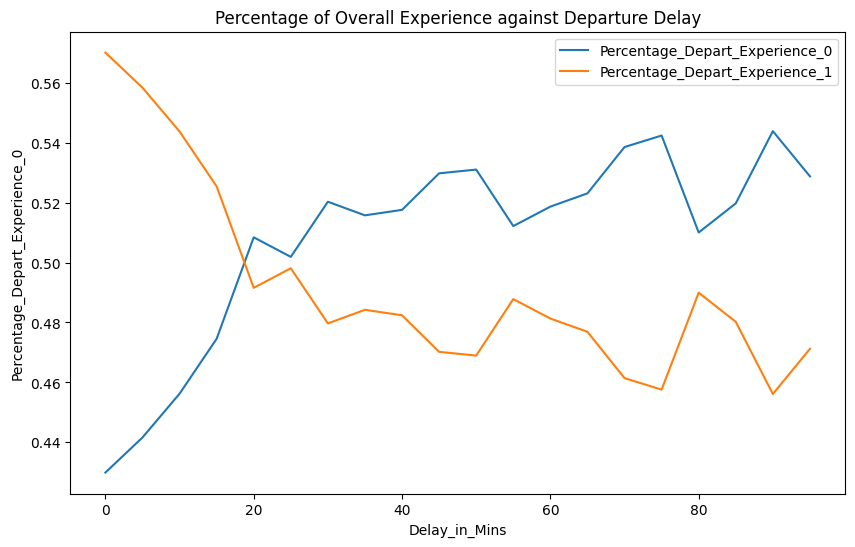

In [32]:
# show a graph of percentage of overall_experience against Departure_Delay_in_Mins
plt.figure(figsize=(10, 6))
sns.lineplot(data=delay_df, x='Delay_in_Mins', y='Percentage_Depart_Experience_0', label='Percentage_Depart_Experience_0')
sns.lineplot(data=delay_df, x='Delay_in_Mins', y='Percentage_Depart_Experience_1', label='Percentage_Depart_Experience_1')
plt.title('Percentage of Overall Experience against Departure Delay')
plt.show()

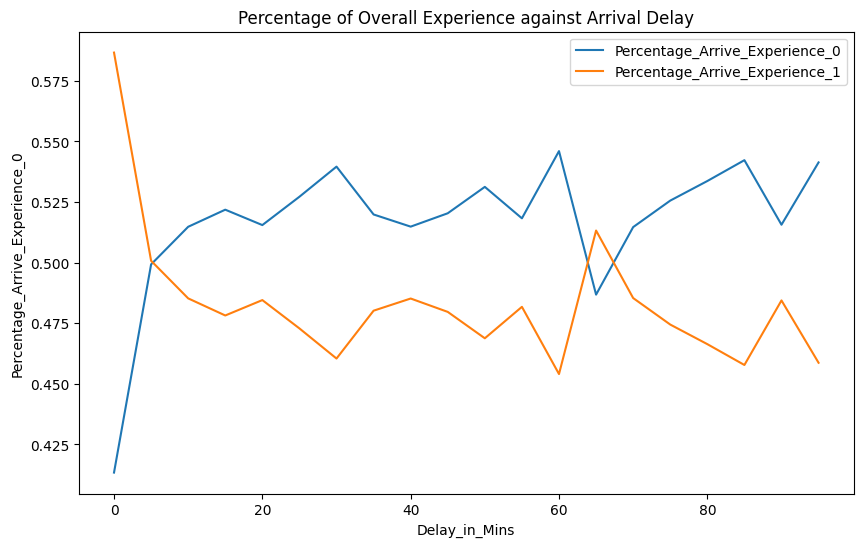

In [33]:
# show a graph of percentage of overall_experience against ArrivaleDelay_in_Mins
plt.figure(figsize=(10, 6))
sns.lineplot(data=delay_df, x='Delay_in_Mins', y='Percentage_Arrive_Experience_0', label='Percentage_Arrive_Experience_0')
sns.lineplot(data=delay_df, x='Delay_in_Mins', y='Percentage_Arrive_Experience_1', label='Percentage_Arrive_Experience_1')
plt.title('Percentage of Overall Experience against Arrival Delay')
plt.show()

####**Observations:**</br>
- More passengers give 0 overall experience score after departure delay of 20 minutes.
- More passengers give 0 overall experience score after arrival delay of 5 minutes.
- Some anomalities in arrival delay of 65 minutes.

####**Examine effect of age on overal experience**

In [34]:
# Create a list to store the data for the DataFrame
data = []

# Iterate through departure delays from 0 to 100
step = 2
start = 7
end = 85
for age in range(start,end,step):
  # Count 'Overall_Experience' values of 1 and 0 for each delay
  count_1 = Merged_train_df[(Merged_train_df['Age'].between(age,age+step-1) ) & (Merged_train_df['Overall_Experience'] == 1)].shape[0]
  count_0 = Merged_train_df[(Merged_train_df['Age'].between(age,age+step-1) ) & (Merged_train_df['Overall_Experience'] == 0)].shape[0]

  # Append data to the list
  data.append([age, count_1, count_0])

# Create the DataFrame
age_df = pd.DataFrame(data, columns=['Age', 'Experience_1', 'Experience_0'])

# Calculate cumulative sums
#delay_df['Cumulative_Experience_1'] = delay_df['Overall_Experience_1'].cumsum()
#delay_df['Cumulative_Experience_0'] = delay_df['Overall_Experience_0'].cumsum()

# Add percentage columns
age_df['Percentage_1'] = age_df['Experience_1'] / (age_df['Experience_1'] + age_df['Experience_0'])
age_df['Percentage_0'] = age_df['Experience_0'] / (age_df['Experience_1'] + age_df['Experience_0'])

age_df.head()

,Age,Experience_1,Experience_0,Percentage_1,Percentage_0
0,7,454,623,0.421541,0.578459
1,9,508,740,0.407051,0.592949
2,11,526,652,0.446520,0.553480
3,13,515,694,0.425972,0.574028
4,15,654,893,0.422754,0.577246


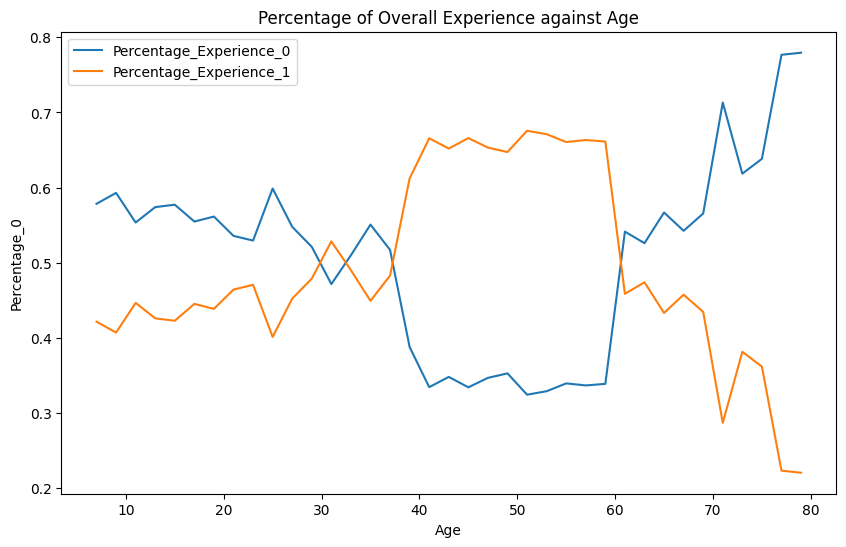

In [35]:
# show a graph of percentage of overall_experience against Age
plt.figure(figsize=(10, 6))
sns.lineplot(data=age_df, x='Age', y='Percentage_0', label='Percentage_Experience_0')
sns.lineplot(data=age_df, x='Age', y='Percentage_1', label='Percentage_Experience_1')
plt.title('Percentage of Overall Experience against Age')
plt.show()

####**Observation:**
- Ages between 38-60 give higher overall experience

####**Examine effect of travel distance on overal experience**

In [36]:
# Create a list to store the data for the DataFrame
data = []

# Iterate through departure delays from 0 to 100
step = 50
start = 50
end = 4000
for dist in range(start,end,step):
  # Count 'Overall_Experience' values of 1 and 0 for each delay
  count_1 = Merged_train_df[(Merged_train_df['Travel_Distance'].between(dist,dist+step-1) ) & (Merged_train_df['Overall_Experience'] == 1)].shape[0]
  count_0 = Merged_train_df[(Merged_train_df['Travel_Distance'].between(dist,dist+step-1) ) & (Merged_train_df['Overall_Experience'] == 0)].shape[0]

  # Append data to the list
  data.append([dist, count_1, count_0])

# Create the DataFrame
dist_df = pd.DataFrame(data, columns=['Distance', 'Experience_1', 'Experience_0'])

# Calculate cumulative sums
#delay_df['Cumulative_Experience_1'] = delay_df['Overall_Experience_1'].cumsum()
#delay_df['Cumulative_Experience_0'] = delay_df['Overall_Experience_0'].cumsum()

# Add percentage columns
dist_df['Percentage_1'] = dist_df['Experience_1'] / (dist_df['Experience_1'] + dist_df['Experience_0'])
dist_df['Percentage_0'] = dist_df['Experience_0'] / (dist_df['Experience_1'] + dist_df['Experience_0'])

dist_df.head()

,Distance,Experience_1,Experience_0,Percentage_1,Percentage_0
0,50,778,268,0.743786,0.256214
1,100,251,84,0.749254,0.250746
2,150,2,3,0.400000,0.600000
3,200,861,290,0.748045,0.251955
4,250,904,315,0.741591,0.258409


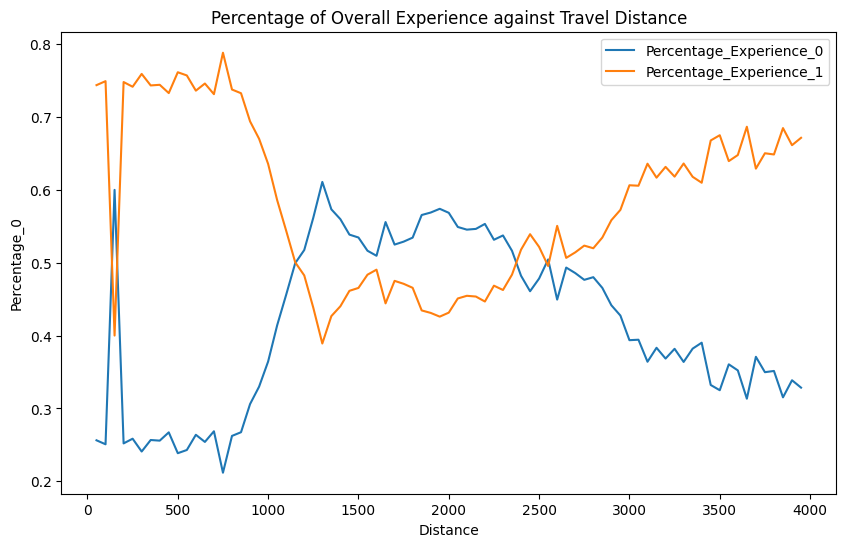

In [37]:
# show a graph of percentage of overall_experience against travel distance
plt.figure(figsize=(10, 6))
sns.lineplot(data=dist_df, x='Distance', y='Percentage_0', label='Percentage_Experience_0')
sns.lineplot(data=dist_df, x='Distance', y='Percentage_1', label='Percentage_Experience_1')
plt.title('Percentage of Overall Experience against Travel Distance')
plt.show()

####**Observation:**
- Passengers have better experience in distances < 1200 and > 2500
- In distances between 1200-2500 passengers have less overall experience

## **Feature Engineering**

### **1. Fill missing values**

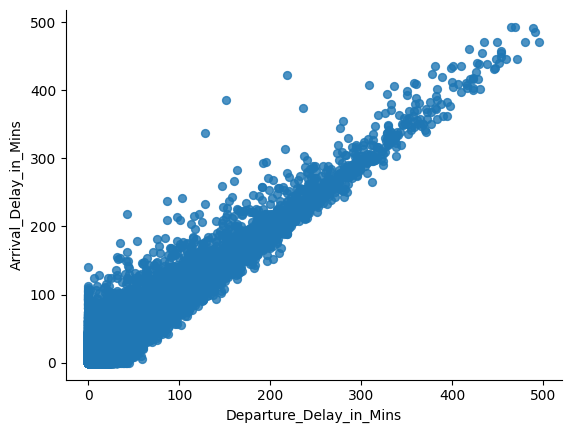

In [38]:
# @title Departure_Delay_in_Mins vs Arrival_Delay_in_Mins

# Create temp_df with only Departure_Delay_in_Mins and Arrival_Delay_in_Mins columns and limit these columns below 500
temp_df = Merged_train_df[['Departure_Delay_in_Mins', 'Arrival_Delay_in_Mins']].copy()
temp_df = temp_df[temp_df['Departure_Delay_in_Mins'] < 500]
temp_df = temp_df[temp_df['Arrival_Delay_in_Mins'] < 500]

from matplotlib import pyplot as plt
temp_df.plot(kind='scatter', x='Departure_Delay_in_Mins', y='Arrival_Delay_in_Mins', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [39]:
# Display rows where 'Departure_Delay_in_Mins' is null and 'Arrival_Delay_in_Mins' is not null
Merged_train_df[Merged_train_df['Departure_Delay_in_Mins'].isnull() & Merged_train_df['Arrival_Delay_in_Mins'].notnull()]

,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins,Overall_Experience,Seat_Comfort,...,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,Onboard_Service,Legroom,Baggage_Handling,CheckIn_Service,Cleanliness,Online_Boarding


In [40]:
# Display rows where 'Departure_Delay_in_Mins' is not null and 'Arrival_Delay_in_Mins' is  null
Merged_train_df[Merged_train_df['Departure_Delay_in_Mins'].notnull() & Merged_train_df['Arrival_Delay_in_Mins'].isnull()].head()

,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins,Overall_Experience,Seat_Comfort,...,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,Onboard_Service,Legroom,Baggage_Handling,CheckIn_Service,Cleanliness,Online_Boarding
230,Male,NaN,27.0,Business Travel,Business,4943,181.0,NaN,1,Poor,...,Good,Acceptable,Acceptable,Good,Good,Excellent,Good,Acceptable,Good,Acceptable
231,Female,Loyal Customer,24.0,Personal Travel,Eco,1711,10.0,NaN,1,Needs Improvement,...,Good,Excellent,Excellent,Excellent,Excellent,Excellent,Excellent,Good,Excellent,Acceptable
265,Female,NaN,37.0,Business Travel,Business,4019,0.0,NaN,0,Good,...,Needs Improvement,Good,Good,Good,NaN,Good,Good,Poor,Good,Good
418,Male,Loyal Customer,58.0,Business Travel,Eco,2399,0.0,NaN,1,Good,...,Excellent,Good,Excellent,Excellent,Poor,Excellent,Excellent,Excellent,Acceptable,Excellent
475,Female,NaN,39.0,Business Travel,Business,2505,0.0,NaN,1,Poor,...,Excellent,Excellent,Good,Good,Good,Good,Good,Excellent,Good,Excellent


####**Observation:**
- Arrival Delay is usually around Departure Delay.
- For missing Arrival_Delay we can use Departure_Delay (if not null)
- If Departure_Delay is null then Arrival_Delay is also null, so we can't use Arrival_Delay to fill missing Departure_Delay
- Otherwise most frequent delay is 0

In [41]:
# @title Fix null Arrival_Delay and Departure_Delay

# Fix missing Arrival_Delay_in_Mins from Departure_Delay_in_Mins
Merged_train_df.fillna({'Arrival_Delay_in_Mins': Merged_train_df['Departure_Delay_in_Mins']}, inplace=True)
Merged_test_df.fillna({'Arrival_Delay_in_Mins': Merged_test_df['Departure_Delay_in_Mins']}, inplace=True)

# Fix missing Arrival_Delay_in_Mins and Departure_Delay_in_Mins with 0
Merged_train_df.fillna({'Arrival_Delay_in_Mins': 0, 'Departure_Delay_in_Mins': 0}, inplace=True)
Merged_test_df.fillna({'Arrival_Delay_in_Mins': 0, 'Departure_Delay_in_Mins': 0}, inplace=True)


In [42]:
# Convert all numberical columns to int
#Merged_train_df[numerical_columns] = Merged_train_df[numerical_columns].astype(int)
#Merged_test_df[numerical_columns] = Merged_test_df[numerical_columns].astype(int)

In [43]:
# Use simple impute to fill null values in Merged_train_df.
# Numerical will be filled with mean values and categorical will be filled with most-frequent values.

from sklearn.impute import SimpleImputer

# Create separate imputers for numerical and categorical features
median_imputer = SimpleImputer(strategy='median') # for Age, Travel_Distance
most_frequent_imputer = SimpleImputer(strategy='most_frequent') # for categorical

# Fit and transform numerical features
Merged_train_df[numerical_columns] = median_imputer.fit_transform(Merged_train_df[numerical_columns])
Merged_test_df[numerical_columns] = median_imputer.transform(Merged_test_df[numerical_columns])

# Fit and transform categorical features
Merged_train_df[categorical_columns] = most_frequent_imputer.fit_transform(Merged_train_df[categorical_columns])
Merged_test_df[categorical_columns] = most_frequent_imputer.transform(Merged_test_df[categorical_columns])

# Transfor numerical values to int
Merged_train_df[numerical_columns] = Merged_train_df[numerical_columns].astype(int)
Merged_test_df[numerical_columns] = Merged_test_df[numerical_columns].astype(int)

# Check for null values in train
print ('Number of null values in Merged_train_df:', Merged_train_df.isnull().sum().sum())
print ('Number of null values in Merged_test_df:', Merged_test_df.isnull().sum().sum())

Number of null values in Merged_train_df: 0
Number of null values in Merged_test_df: 0


### **remove outliers**

### **2. Create output vector**

In [44]:
# Move 'Overall_Experience' from Merged_train_df to output y
y = Merged_train_df.pop('Overall_Experience')

In [45]:
Merged_train_df.head()

,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins,Seat_Comfort,Seat_Class,...,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,Onboard_Service,Legroom,Baggage_Handling,CheckIn_Service,Cleanliness,Online_Boarding
0,Female,Loyal Customer,52,Business Travel,Business,272,0,5,Needs Improvement,Green Car,...,Good,Needs Improvement,Acceptable,Needs Improvement,Needs Improvement,Acceptable,Needs Improvement,Good,Needs Improvement,Poor
1,Male,Loyal Customer,48,Personal Travel,Eco,2200,9,0,Poor,Ordinary,...,Good,Poor,Good,Good,Excellent,Needs Improvement,Poor,Needs Improvement,Good,Good
2,Female,Loyal Customer,43,Business Travel,Business,1061,77,119,Needs Improvement,Green Car,...,Needs Improvement,Good,Excellent,Excellent,Excellent,Excellent,Excellent,Good,Excellent,Excellent
3,Female,Loyal Customer,44,Business Travel,Business,780,13,18,Acceptable,Ordinary,...,Acceptable,Needs Improvement,Acceptable,Acceptable,Acceptable,Acceptable,Acceptable,Good,Acceptable,Acceptable
4,Female,Loyal Customer,50,Business Travel,Business,1981,0,0,Acceptable,Ordinary,...,Needs Improvement,Good,Excellent,Good,Good,Good,Good,Good,Good,Good


In [46]:
Merged_test_df.head()

,Gender,Customer_Type,Age,Type_Travel,Travel_Class,Travel_Distance,Departure_Delay_in_Mins,Arrival_Delay_in_Mins,Seat_Comfort,Seat_Class,...,Onboard_Wifi_Service,Onboard_Entertainment,Online_Support,Ease_of_Online_Booking,Onboard_Service,Legroom,Baggage_Handling,CheckIn_Service,Cleanliness,Online_Boarding
0,Female,Loyal Customer,36,Business Travel,Business,532,0,0,Acceptable,Green Car,...,Needs Improvement,Excellent,Good,Excellent,Excellent,Excellent,Excellent,Good,Excellent,Poor
1,Female,Disloyal Customer,21,Business Travel,Business,1425,9,28,Extremely Poor,Ordinary,...,Acceptable,Poor,Acceptable,Acceptable,Excellent,Acceptable,Good,Acceptable,Excellent,Acceptable
2,Male,Loyal Customer,60,Business Travel,Business,2832,0,0,Excellent,Ordinary,...,Excellent,Excellent,Excellent,Needs Improvement,Needs Improvement,Needs Improvement,Needs Improvement,Good,Needs Improvement,Excellent
3,Female,Loyal Customer,29,Personal Travel,Eco,1352,0,0,Acceptable,Green Car,...,Poor,Acceptable,Excellent,Poor,Acceptable,Needs Improvement,Excellent,Excellent,Excellent,Poor
4,Male,Disloyal Customer,18,Business Travel,Business,1610,17,0,Excellent,Ordinary,...,Excellent,Excellent,Excellent,Excellent,Good,Acceptable,Excellent,Excellent,Excellent,Excellent


In [47]:
# prompt: look for different row labels between Merged_test_df and Merged_train_df

# Find rows labels present in Merged_test_df but not in Merged_train_df
diff_columns = set(Merged_test_df.columns) - set(Merged_train_df.columns)

print("Rows present in Merged_test_df but not in Merged_train_df:")
print(diff_columns)




Rows present in Merged_test_df but not in Merged_train_df:
set()


In [48]:
# prompt: get number of columns in Merged_train and Merged_test

print("Number of columns in Merged_train:", len(Merged_train_df.columns))
print("Number of columns in Merged_test:", len(Merged_test_df.columns))


Number of columns in Merged_train: 23
Number of columns in Merged_test: 23


In [49]:
# prompt: find which column in Merged_train is missing in Merged_test

diff_columns = set(Merged_test_df.columns) - set(Merged_train_df.columns)
print("Columns present in Merged_test_df but not in Merged_train_df:")
diff_columns


Columns present in Merged_test_df but not in Merged_train_df:


set()

### **3. Skewed data - Cap numerical values with outliers?**

**When Should You Cap the Values?**</br>
-	If extreme values are true outliers (e.g., data entry errors), then clipping might be helpful.
-	If the distribution is highly skewed and causing instability in the model, try binning, log transformation, or standardization instead of capping.

**Recommended Approach for Random Forest:**</br>
-	Try the raw data first (Random Forest is robust to skew).
-	If feature importance shows the variable is noisy, experiment with:
-	Log transformation (log(1 + x))


```
Merged_train_df['Arrival_Delay_log'] = np.log1p(Merged_train_df['Arrival_Delay_in_Mins'])
```


-	Winsorization (Capping at the 99th percentile instead of an arbitrary 3000)
-	Feature binning (e.g., grouping into categories like “low,” “medium,” “high”).

In [50]:
# @title Cap outliers - rows with numerical values larger than 99%

def cap_outliers(train_df, test_df, columns, quantile=0.99):
  """Cap outliers from a DataFrame

  Args:
    df: The pandas DataFrame.
    columns: A list of column names to check for outliers.
    threshold: The IQR multiplier to define outliers.

  Returns:
    A new DataFrame with outliers removed.
  """
  train_df_copy = train_df.copy()
  test_df_copy = test_df.copy()

  for column in columns:
    upper_bound = train_df[column].quantile(quantile)

    train_df_copy.loc[train_df_copy[column] > upper_bound, column] = upper_bound
    test_df_copy.loc[test_df_copy[column] > upper_bound, column] = upper_bound

  return train_df_copy, test_df_copy



numerical_columns_to_check = ['Arrival_Delay_in_Mins', 'Departure_Delay_in_Mins', 'Travel_Distance']  # Replace with your actual numerical columns
Merged_train_df_capped, Merged_test_df_capped = cap_outliers(Merged_train_df,
                                                             Merged_test_df,
                                                             numerical_columns_to_check,
                                                             quantile=0.99)


In [51]:
# # try log transformation on Arrival_Delay_in_Min, Departure_Delay and Travel_Distance
# for col in numerical_columns_to_check:
#   Merged_train_df_capped[col + '_log'] = np.log1p(Merged_train_df_capped[col])
#   Merged_test_df_capped[col + '_log'] = np.log1p(Merged_test_df_capped[col])
#   Merged_train_df_capped.drop(col, axis=1, inplace=True)
#   Merged_test_df_capped.drop(col, axis=1, inplace=True)
#   draw_hist_box(Merged_test_df_capped, col + '_log')


In [52]:
Merged_train_df = Merged_train_df_capped.copy()
Merged_test_df = Merged_test_df_capped.copy()

In [53]:
#draw_hist_box(Merged_train_df, 'Arrival_Delay_log')

### **4. Merge 'poor' with 'extremely poor' ratings**
Most 'extremely_poor' ratings are very rare and could be combined with 'poor':

- Platform_Location (very inconvinient)
- Onboard_Wifi_Service
- Online_Support
- Online_Booking_Ease
- Onboard_Service
- Leg_Room
- Baggage_Handling (no 'extremely poor' category in training)
- CheckIn_Service
- Cleanliness
- Online_Boarding

In [54]:
# Replace 'extremely_poor' values with 'poor' (and 'inconvinient')

merge_dict = {
    'Extremely Poor': 'Poor',  # Merge rare 'extremely poor' into 'poor'
    'Very Inconvenient': 'Inconvenient',  # Merge rare 'extremely inconvinient' into 'poor'
}



replace_columns = ['Platform_Location', 'Onboard_Wifi_Service', 'Online_Support', 'Ease_of_Online_Booking',
                   'Onboard_Service', 'Legroom', 'Baggage_Handling', 'CheckIn_Service', 'Cleanliness', 'Online_Boarding']

for col in replace_columns:
  print(col, 'Before in train:', Merged_train_df[col].unique())
  print(col, 'Before in test:', Merged_test_df[col].unique())
  Merged_train_df[col] = Merged_train_df[col].replace(merge_dict)
  Merged_test_df[col] = Merged_test_df[col].replace(merge_dict)
  print(col, 'After in train:', Merged_train_df[col].unique())
  print(col, 'After in test:', Merged_test_df[col].unique())


Platform_Location Before in train: ['Very Convenient' 'Needs Improvement' 'Manageable' 'Inconvenient'
 'Convenient' 'Very Inconvenient']
Platform_Location Before in test: ['Manageable' 'Very Convenient' 'Needs Improvement' 'Inconvenient'
 'Convenient']
Platform_Location After in train: ['Very Convenient' 'Needs Improvement' 'Manageable' 'Inconvenient'
 'Convenient']
Platform_Location After in test: ['Manageable' 'Very Convenient' 'Needs Improvement' 'Inconvenient'
 'Convenient']
Onboard_Wifi_Service Before in train: ['Good' 'Needs Improvement' 'Acceptable' 'Excellent' 'Poor'
 'Extremely Poor']
Onboard_Wifi_Service Before in test: ['Needs Improvement' 'Acceptable' 'Excellent' 'Poor' 'Good'
 'Extremely Poor']
Onboard_Wifi_Service After in train: ['Good' 'Needs Improvement' 'Acceptable' 'Excellent' 'Poor']
Onboard_Wifi_Service After in test: ['Needs Improvement' 'Acceptable' 'Excellent' 'Poor' 'Good']
Online_Support Before in train: ['Acceptable' 'Good' 'Excellent' 'Poor' 'Needs Improveme

In [55]:
train_cat = get_categories(Merged_train_df)
train_cat

,0,1,2,3,4,5
Gender,Female,Male,-,-,-,-
Customer_Type,Loyal Customer,Disloyal Customer,-,-,-,-
Type_Travel,Business Travel,Personal Travel,-,-,-,-
Travel_Class,Business,Eco,-,-,-,-
Seat_Comfort,Needs Improvement,Poor,Acceptable,Good,Excellent,Extremely Poor
Seat_Class,Green Car,Ordinary,-,-,-,-
Arrival_Time_Convenient,Excellent,Needs Improvement,Acceptable,Good,Poor,Extremely Poor
Catering,Excellent,Poor,Needs Improvement,Acceptable,Good,Extremely Poor
Platform_Location,Very Convenient,Needs Improvement,Manageable,Inconvenient,Convenient,-
Onboard_Wifi_Service,Good,Needs Improvement,Acceptable,Excellent,Poor,-


In [56]:
test_cat = get_categories(Merged_test_df)
test_cat

,0,1,2,3,4,5
Gender,Female,Male,-,-,-,-
Customer_Type,Loyal Customer,Disloyal Customer,-,-,-,-
Type_Travel,Business Travel,Personal Travel,-,-,-,-
Travel_Class,Business,Eco,-,-,-,-
Seat_Comfort,Acceptable,Extremely Poor,Excellent,Poor,Needs Improvement,Good
Seat_Class,Green Car,Ordinary,-,-,-,-
Arrival_Time_Convenient,Acceptable,Good,Excellent,Extremely Poor,Needs Improvement,Poor
Catering,Acceptable,Poor,Excellent,Needs Improvement,Good,Extremely Poor
Platform_Location,Manageable,Very Convenient,Needs Improvement,Inconvenient,Convenient,-
Onboard_Wifi_Service,Needs Improvement,Acceptable,Excellent,Poor,Good,-


### **5. Create one-hot dummies**

In [57]:
print('Size of train data before one-hot:',Merged_train_df.shape)
print('Size of test data before one-hot:',Merged_test_df.shape)

# Create one-hot categories
Merged_train_df = pd.get_dummies(Merged_train_df, columns=categorical_columns)
Merged_test_df = pd.get_dummies(Merged_test_df, columns=categorical_columns)

print('Size of train data after one-hot:',Merged_train_df.shape)
print('Size of test data after one-hot:',Merged_test_df.shape)

Size of train data before one-hot: (94379, 23)
Size of test data before one-hot: (35602, 23)
Size of train data after one-hot: (94379, 88)
Size of test data after one-hot: (35602, 88)


### **6. Create X_train, y_train, X_test, y_test from data**

In [58]:
# Create 80-20 train-test sets from Merged_train_df
from sklearn.model_selection import train_test_split

X = Merged_train_df

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## **Build Models**
1. Decision Tree
2. Random Forest
3. XGBoost
4. CatBoost

### **Load libraries**

In [59]:
# # Algorithms to use
# from sklearn import tree

# from sklearn.tree import DecisionTreeClassifier

# from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier

# from xgboost import XGBClassifier

# !pip install --upgrade --force-reinstall catboost
# import catboost


# from catboost import CatBoostClassifier

# # Metrics to evaluate the model
# from sklearn import metrics

# from sklearn.metrics import confusion_matrix, classification_report,recall_score,precision_score, accuracy_score

# # For tuning the model
# from sklearn.model_selection import GridSearchCV, cross_val_score

# try:
#   import optuna
# except ImportError:
#   !pip install optuna
#   import optuna



### **Helper Functions**

In [60]:
# Creating metric function

def metrics_score(actual, predicted):

    print(classification_report(actual, predicted))

    cm = confusion_matrix(actual, predicted)

    plt.figure(figsize = (8, 5))

    sns.heatmap(cm, annot = True, fmt = '.2f', xticklabels = ['0', '1'], yticklabels = ['0', '1'])
    plt.ylabel('Actual')

    plt.xlabel('Predicted')

    plt.show()

In [61]:
def model_performance_classification(model_name, model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model_name: model name
    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # Predicting using the independent variables
    pred = model.predict(predictors)

    recall = round(100*recall_score(target, pred,average = 'macro'),2)         # To compute recall

    precision = round(100*precision_score(target, pred, average = 'macro'),2)   # To compute precision

    acc = round(100*accuracy_score(target, pred),2)                             # To compute accuracy score


    # Creating a dataframe of metrics

    df_perf = pd.DataFrame(
        {
            "Model": model_name,
            "Precision":  precision,
            "Recall":  recall,
            "Accuracy": acc,
        },

        index = [0],
    )

    return df_perf

In [62]:
# Dataframe to register all models scores
scores_df = pd.DataFrame(columns=['Model', 'Precision', 'Recall', 'Accuracy'])

# Function to add new model scores to scores_df
def add_score(total_scores_df,df_perf):
  """
    Function to add scores to scores_df

    total_scores_df: dataframe of all models scores
    df_perf: dataframe of new model scores
    """
  return pd.concat([total_scores_df, df_perf], ignore_index=True)


In [63]:
# Show most important features

def show_important_features(estimator_model, X, min_inportance=None):
  """
    Function to show the most important features in desc order

    estimator_model: model to use
    X: independent variables
    """
  importances = estimator_model.feature_importances_

  columns = X.columns

  importance_df = pd.DataFrame(importances, index = columns, columns = ['Importance']).sort_values(by = 'Importance', ascending = False)
  if min_inportance:
    importance_df = importance_df[importance_df['Importance'] >= min_inportance]

  plt.figure(figsize = (13, 13))

  sns.barplot(x= importance_df.Importance, y=importance_df.index);
  plt.xlabel('Feature Importance Score')
  plt.ylabel('Features')
  plt.title("Visualizing Important Features")
  plt.show()

In [64]:
# Function to analyse octuna results - top10 best and worst params

def show_octuna_trials(octuna_study):

  trials = octuna_study.get_trials()
  sorted_trials = sorted(trials, key=lambda x: x.value, reverse=True)

  print("Top 10 Results (Highest to Lowest):")
  for i, trial in enumerate(sorted_trials[:10]):
      print(f"Rank {i+1}: Value: {trial.value}, Parameters: {trial.params}")
  print('-'*10)
  print("Worst 10 Results (Lowest to Highest):")
  for i, trial in enumerate(sorted_trials[-10:]):
      print(f"Rank {i+1}: Value: {trial.value}, Parameters: {trial.params}")
  print('-'*10)
  print("Best Parameters:")
  print(octuna_study.best_params)

### **Model-1: Decision Tree**

In [65]:
# Create DecisionTree model


Decision Tree Classifier:
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      8405
           1       0.93      0.94      0.93     10471

    accuracy                           0.93     18876
   macro avg       0.93      0.93      0.93     18876
weighted avg       0.93      0.93      0.93     18876



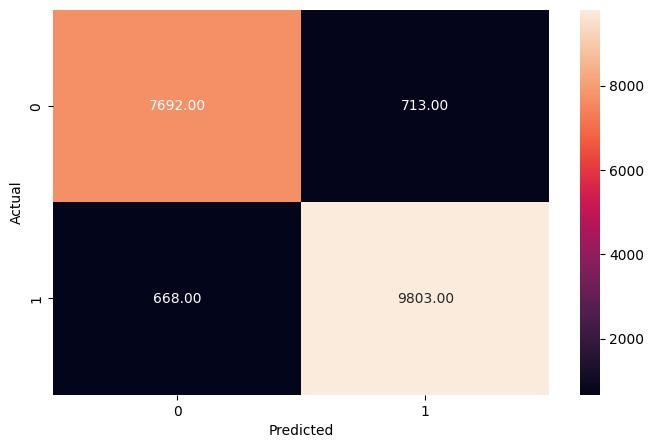

,Model,Precision,Recall,Accuracy
0,DecisionTree,92.61,92.57,92.68


In [66]:
# @title Create DecisionTree model

# Create DecisionTreeClassifier model
dt_model = DecisionTreeClassifier(class_weight="balanced", random_state=42)

# Fit the model to the training data
dt_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_dt = dt_model.predict(X_test)

# Evaluate the model
print("Decision Tree Classifier:")
metrics_score(y_test, y_pred_dt)
df_perf_dt = model_performance_classification('DecisionTree',dt_model, X_test, y_test)
df_perf_dt


In [67]:
# Register new model scores
scores_df = add_score(scores_df,df_perf_dt)
scores_df

,Model,Precision,Recall,Accuracy
0,DecisionTree,92.61,92.57,92.68


In [68]:
# @title Create DecisionTree model with hyper-parameters tuning

# Define the objective function for Optuna
def objective(trial):
    # Define the hyperparameter search space
    #criterion = trial.suggest_categorical("criterion", ["gini", "entropy"])
    max_depth = trial.suggest_int("max_depth", 10, 32, log=True)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 100)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

    # Create the DecisionTreeClassifier model with the suggested hyperparameters
    dt_model = DecisionTreeClassifier(
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",
        random_state=42,
    )

    # Fit the model to the training data
    dt_model.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = dt_model.predict(X_test)

    # Evaluate the model using accuracy
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

# Create an Optuna study
study = optuna.create_study(direction="maximize")

# Optimize the objective function
#study.optimize(objective, n_trials=50) # You can adjust the number of trials

# Get the best hyperparameters
#best_params = study.best_params

# Create a DecisionTreeClassifier model with the best hyperparameters
#best_dt_model = DecisionTreeClassifier(**best_params, random_state=42)

# Fit the best model to the training data
#best_dt_model.fit(X_train, y_train)

# Make predictions on the test data using the best model
#y_pred_best_dt = best_dt_model.predict(X_test)


[I 2025-03-20 12:58:49,411] A new study created in memory with name: no-name-41457ba3-55cd-4ef5-ac9f-65818f2b09f5


In [69]:
# Evaluate the best model
#print("Decision Tree Classifier (Tuned):")
#metrics_score(y_test, y_pred_best_dt)
#df_perf_best_dt = model_performance_classification('DecisionTree_Tuned', best_dt_model, X_test, y_test)
#print(df_perf_best_dt)

# Register the tuned model's scores
#scores_df = add_score(scores_df, df_perf_best_dt)


In [70]:
scores_df

,Model,Precision,Recall,Accuracy
0,DecisionTree,92.61,92.57,92.68


In [71]:
# Show best parameters for DecisionTreeClassifier after tuning
#best_params

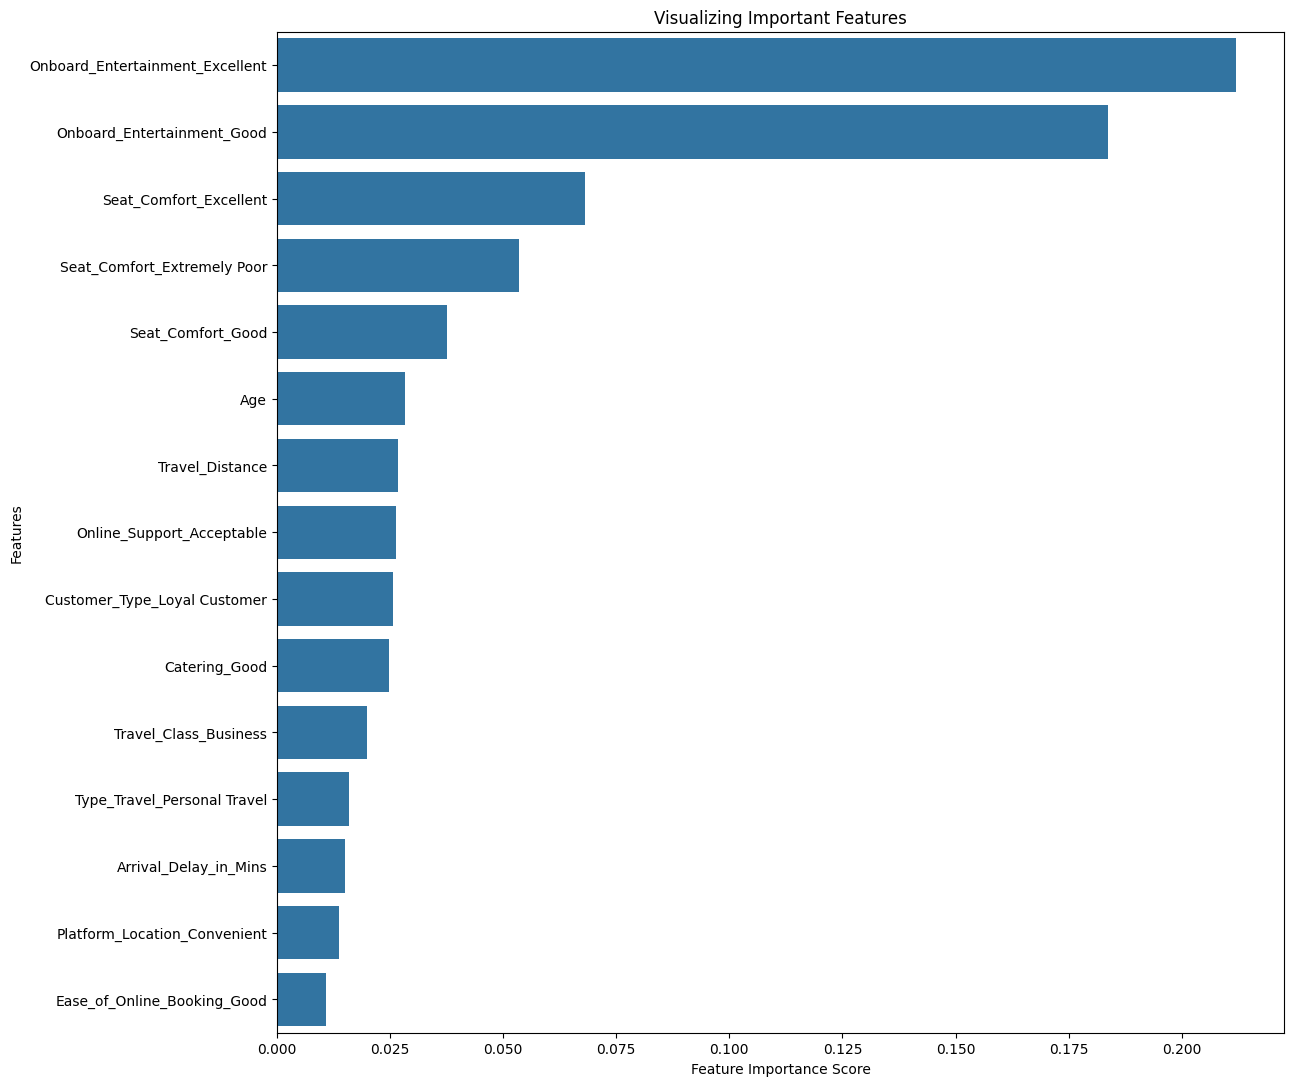

In [72]:
show_important_features(dt_model, X_test, 0.01)

### **Model-2: Random Forest**

Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      8405
           1       0.96      0.95      0.96     10471

    accuracy                           0.95     18876
   macro avg       0.95      0.95      0.95     18876
weighted avg       0.95      0.95      0.95     18876



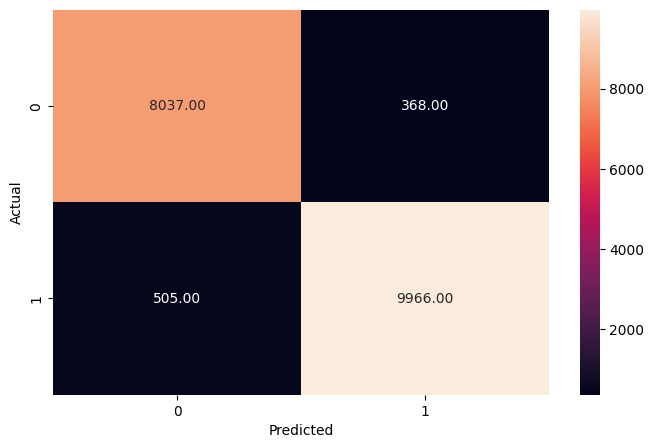

          Model  Precision  Recall  Accuracy
0  RandomForest      95.26    95.4     95.38


In [73]:
# @title Create a RandomForest model with default parameters

params = {
    'n_estimators': 500,
    'max_depth': 32,
} # score 95.45

# Create RandomForestClassifier model with default parameters
rf_model = RandomForestClassifier(**params, class_weight="balanced", random_state=42)

# Fit the model to the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Classifier:")
metrics_score(y_test, y_pred_rf)
df_perf_rf = model_performance_classification('RandomForest', rf_model, X_test, y_test)
print(df_perf_rf)

# Register the model's scores
scores_df = add_score(scores_df, df_perf_rf)


In [74]:
# @title Create RandomForest model with optuna hyper-parameters optimization

# def objective(trial):
#     # Define the hyperparameter search space
#     n_estimators = trial.suggest_int("n_estimators", 300, 500) # changed 50 to 400
#     max_depth = trial.suggest_int("max_depth", 24, 32, log=True) # changed from 2-32
#     min_samples_split = trial.suggest_int("min_samples_split", 2, 4) # changed from 2-100
#     #min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 100)

#     # Create the RandomForestClassifier model with the suggested hyperparameters
#     rf_model = RandomForestClassifier(
#         n_estimators=n_estimators,
#         max_depth=max_depth,
#         min_samples_split=min_samples_split,
#         #min_samples_leaf=min_samples_leaf,
#         n_jobs=-1,
#         class_weight="balanced",
#         random_state=42,
#     )

#     # Fit the model to the training data
#     rf_model.fit(X_train, y_train)

#     # Make predictions on the test data
#     y_pred = rf_model.predict(X_test)

#     # Evaluate the model using accuracy
#     accuracy = accuracy_score(y_test, y_pred)
#     return accuracy

# # Create an Optuna study
# study = optuna.create_study(direction="maximize")

# # Optimize the objective function
# study.optimize(objective, n_trials=50) # You can adjust the number of trials

# # Get the best hyperparameters
# best_params = study.best_params

# # Create a RandomForestClassifier model with the best hyperparameters
# best_rf_model = RandomForestClassifier(**best_params, random_state=42)

# # Fit the best model to the training data
# best_rf_model.fit(X_train, y_train)

# # Make predictions on the test data using the best model
# y_pred_best_rf = best_rf_model.predict(X_test)


In [75]:
# show_octuna_trials(study)

In [76]:

# # Get the best hyperparameters
# best_params = study.best_params

# # Create a RandomForestClassifier model with the best hyperparameters
# best_rf_model = RandomForestClassifier(**best_params, class_weight="balanced", random_state=42)

# # Fit the best model to the training data
# best_rf_model.fit(X_train, y_train)

# # Make predictions on the test data using the best model
# y_pred_best_rf = best_rf_model.predict(X_test)


In [77]:
# # Evaluate the best model
# print("Random Forest Classifier (Tuned):")
# metrics_score(y_test, y_pred_best_rf)
# df_perf_best_rf = model_performance_classification('RandomForest_Tuned', best_rf_model, X_test, y_test)

# # Register the tuned model's scores
# scores_df = add_score(scores_df, df_perf_best_rf)
# scores_df


In [78]:
# prompt: train randomforest with gridsearchcv

# @title Create RandomForest model with hyper-parameters optimization using GridSearchCV

from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [None, 32, 34, 35],
    'class_weight': ['balanced'],
}

# Create the RandomForestClassifier model
rf_model = RandomForestClassifier(random_state=42)

# Create the GridSearchCV object
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Fit the model to the training data
grid_search_rf.fit(X_train, y_train)




Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'class_weight': ['balanced'],
                         'max_depth': [None, 32, 34, 35],
                         'n_estimators': [300, 500]},
             scoring='accuracy', verbose=2)

In [79]:
# Get the best hyperparameters
best_rf_params = grid_search_rf.best_params_

# Create a RandomForestClassifier model with the best hyperparameters
best_rf_model = RandomForestClassifier(**best_rf_params, random_state=42)

# Fit the best model to the training data
best_rf_model.fit(X_train, y_train)

# Make predictions on the test data using the best model
y_pred_best_rf = best_rf_model.predict(X_test)


In [80]:
# Show best parameters for RandomForestClassifier after tuning
best_rf_params

{'class_weight': 'balanced', 'max_depth': None, 'n_estimators': 500}

Random Forest Classifier (Tuned with GridSearchCV):
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      8405
           1       0.96      0.95      0.96     10471

    accuracy                           0.95     18876
   macro avg       0.95      0.95      0.95     18876
weighted avg       0.95      0.95      0.95     18876



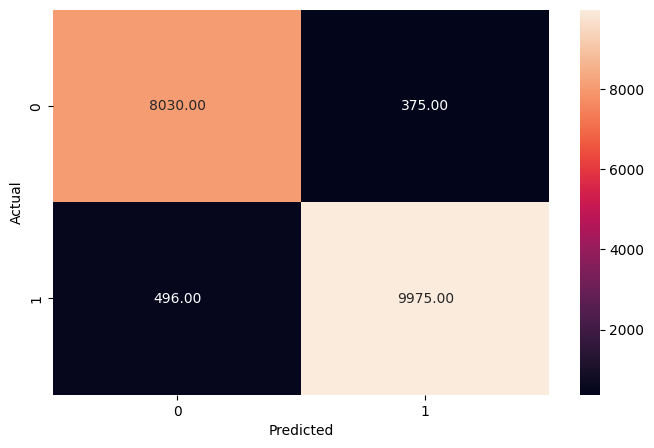

                       Model  Precision  Recall  Accuracy
0  RandomForest_GridSearchCV      95.28    95.4     95.39


,Model,Precision,Recall,Accuracy
0,DecisionTree,92.61,92.57,92.68
1,RandomForest,95.26,95.40,95.38
2,RandomForest_GridSearchCV,95.28,95.40,95.39


In [81]:

# Evaluate the best model
print("Random Forest Classifier (Tuned with GridSearchCV):")
metrics_score(y_test, y_pred_best_rf)
df_perf_best_rf = model_performance_classification('RandomForest_GridSearchCV', best_rf_model, X_test, y_test)
print(df_perf_best_rf)

# Register the tuned model's scores
scores_df = add_score(scores_df, df_perf_best_rf)

scores_df

In [82]:
# show_important_features(best_rf_model, X_test,0.01)

In [83]:
# Get the results
results = grid_search_rf.cv_results_

# Create a DataFrame from the results for easier viewing
results_df = pd.DataFrame(results).sort_values(by='mean_test_score', ascending=False)

# Print or display the DataFrame
display(results_df)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_class_weight,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1,69.839441,0.412761,1.651532,0.031735,balanced,None,500,"{'class_weight': 'balanced', 'max_depth': None...",0.951262,0.950401,0.949672,0.953113,0.953444,0.951578,0.001480,1
7,66.676068,7.933467,1.895190,0.525629,balanced,35,500,"{'class_weight': 'balanced', 'max_depth': 35, ...",0.951328,0.949937,0.949606,0.953046,0.953642,0.951512,0.001615,2
0,42.968558,0.823455,1.349332,0.374516,balanced,None,300,"{'class_weight': 'balanced', 'max_depth': None...",0.951195,0.950533,0.949474,0.952848,0.953046,0.951419,0.001364,3
5,68.439436,2.168361,1.687237,0.057567,balanced,34,500,"{'class_weight': 'balanced', 'max_depth': 34, ...",0.951394,0.949805,0.949672,0.953179,0.952649,0.951340,0.001431,4
4,40.476465,1.256831,1.231403,0.263377,balanced,34,300,"{'class_weight': 'balanced', 'max_depth': 34, ...",0.951593,0.949937,0.949871,0.953179,0.952053,0.951326,0.001271,5
3,69.374587,0.825817,2.489377,0.322530,balanced,32,500,"{'class_weight': 'balanced', 'max_depth': 32, ...",0.951460,0.950070,0.948878,0.953113,0.952517,0.951207,0.001558,6
6,42.433358,0.264513,1.279424,0.325451,balanced,35,300,"{'class_weight': 'balanced', 'max_depth': 35, ...",0.951195,0.949738,0.949341,0.952119,0.953179,0.951115,0.001436,7
2,41.724101,0.363937,1.053328,0.107256,balanced,32,300,"{'class_weight': 'balanced', 'max_depth': 32, ...",0.951262,0.949474,0.949738,0.952185,0.951722,0.950876,0.001081,8


### **Model-3: XGBoost model**

XGBoost Classifier:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      8405
           1       0.97      0.95      0.96     10471

    accuracy                           0.96     18876
   macro avg       0.95      0.96      0.95     18876
weighted avg       0.96      0.96      0.96     18876



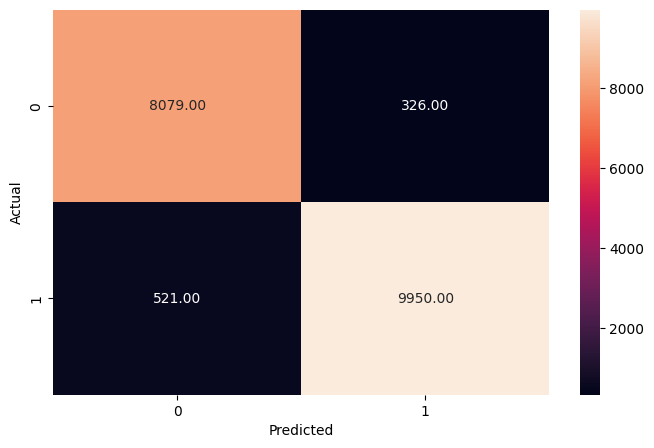

     Model  Precision  Recall  Accuracy
0  XGBoost      95.38   95.57     95.51


In [84]:
# @title Create XGBoost model with default parameters

# Compute scale_pos_weight
scale_pos_weight = sum(y_train == 0) / sum(y_train == 1)

{'n_estimators': 525,
 'max_depth': 14,
 'learning_rate': 0.031933503417110785,
 'subsample': 0.8947727387883666,
 'colsample_bytree': 0.6068160744995746,
 'gamma': 0.1103139841238927,
 'lambda': 0.04039831279920262,
 'alpha': 0.029585341310597726}

# Create XGBClassifier model with default parameters
xgb_model = XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42)

# Fit the model to the training data
xgb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
print("XGBoost Classifier:")
metrics_score(y_test, y_pred_xgb)
df_perf_xgb = model_performance_classification('XGBoost', xgb_model, X_test, y_test)
print(df_perf_xgb)

# Register the model's scores
scores_df = add_score(scores_df, df_perf_xgb)


XGBoost Classifier:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      8405
           1       0.97      0.96      0.96     10471

    accuracy                           0.96     18876
   macro avg       0.96      0.96      0.96     18876
weighted avg       0.96      0.96      0.96     18876



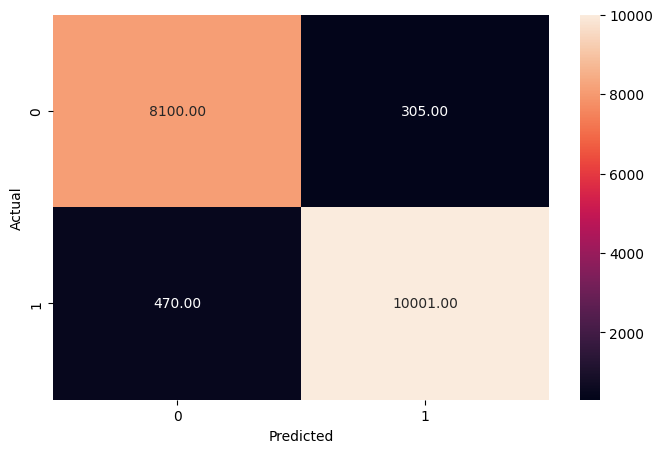

                Model  Precision  Recall  Accuracy
0  XGBoost_pre-params      95.78   95.94     95.89


In [85]:
# @title Create XGBoost model with pre-optimized parameters

# Parameters from pre-optimized optuna trial (rounded)
params = {'n_estimators': 525,
          'max_depth': 14,
          'learning_rate': 0.03,
          'subsample': 0.89,
          'colsample_bytree': 0.60,
          'gamma': 0.11,
          'lambda': 0.04,
          'alpha': 0.03} # score 95.84

params = {'n_estimators': 600,
          'max_depth': 13,
          'learning_rate': 0.03939713510926439,
          'subsample': 0.8611787978244437,
          'colsample_bytree': 0.5966705464174542,
          'gamma': 0.08085888095680066,
          'lambda': 0.0265967235050519,
          'alpha': 0.07665904555757651} # score 95.85

params = {'n_estimators': 575,
          'max_depth': 14,
          'learning_rate': 0.031074747005213996,
          'subsample': 0.9308851106559048,
          'colsample_bytree': 0.6382642340617781,
          'gamma': 0.1115630576120649,
          'lambda': 0.13081185823521863,
          'alpha': 0.0019371039617967329} # score 95.96 (95.78?)

# params =  {'n_estimators': 425,
#           'max_depth': 13,
#           'learning_rate': 0.047708251909174895,
#           'subsample': 0.9106777157058713,
#           'colsample_bytree': 0.6762526605572227,
#           'gamma': 0.009436775212533149,
#           'lambda': 0.973901964509158,
#           'alpha': 0.06398755499534443} # score 95.94

# Create XGBClassifier model with parameters
xgb_params_model = XGBClassifier(**params,
                                scale_pos_weight=scale_pos_weight,
                                device='cuda',
                                random_state=42, eval_metric='logloss')

# Fit the model to the training data
xgb_params_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xgb = xgb_params_model.predict(X_test)

# Evaluate the model
print("XGBoost Classifier:")
metrics_score(y_test, y_pred_xgb)
df_perf_xgb = model_performance_classification('XGBoost_pre-params', xgb_params_model, X_test, y_test)
print(df_perf_xgb)

# Register the model's scores
scores_df = add_score(scores_df, df_perf_xgb)


In [86]:
# @title Create XGBoost model with hyper-parameters optimization

def objective(trial):
    # Define the hyperparameter search space
    n_estimators = trial.suggest_int("n_estimators", 400, 600, step=25)
    max_depth = trial.suggest_int("max_depth", 12, 14) # 12-14 instead 12-16
    learning_rate = trial.suggest_float("learning_rate", 0.02, 0.08, log=True) # 0.1-1 to 0.02-0.08
    subsample = trial.suggest_float("subsample", 0.7, 1.0) # 0.5-1 to 0.7-1
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 0.9) # 0.5-1 to 0.5-0.9
    gamma = trial.suggest_float('gamma', 0, 0.5, log=False) # 0-1 to 0-0.5
    reg_lambda = trial.suggest_float('lambda', 1e-3, 1, log=True) # change 10 to 1
    reg_alpha = trial.suggest_float('alpha', 0, 0.1, log=False) # change 1e-3 - 1 to 0-0.1 Log=False

    # Create the XGBoost model with the suggested hyperparameters
    xgb_model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        device='cuda',
        gamma=gamma,
        reg_lambda=reg_lambda,
        reg_alpha=reg_alpha,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    )

    # Fit the model to the training data
    xgb_model.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = xgb_model.predict(X_test)

    # Evaluate the model using accuracy
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

# Create an Optuna study
study = optuna.create_study(direction="maximize")

# Optimize the objective function
study.optimize(objective, n_trials=100)  # You can adjust the number of trials

# Get the best hyperparameters
best_xgb_params = study.best_params

# Create an XGBoost model with the best hyperparameters
best_xgb_model = XGBClassifier(**best_xgb_params,
                               scale_pos_weight=scale_pos_weight,
                               device='cuda',
                               random_state=42, eval_metric='logloss')

# Fit the best model to the training data
best_xgb_model.fit(X_train, y_train)

# Make predictions on the test data using the best model
y_pred_best_xgb = best_xgb_model.predict(X_test)



[I 2025-03-20 13:21:08,459] A new study created in memory with name: no-name-d9cb0b69-9f39-4147-b6f8-91c541569cc4
[I 2025-03-20 13:21:12,787] Trial 0 finished with value: 0.9578830260648442 and parameters: {'n_estimators': 425, 'max_depth': 14, 'learning_rate': 0.059387985824464626, 'subsample': 0.7601727909872047, 'colsample_bytree': 0.6702351011707413, 'gamma': 0.41407221709957454, 'lambda': 0.006088851714683308, 'alpha': 0.08904116642578781}. Best is trial 0 with value: 0.9578830260648442.
[I 2025-03-20 13:21:18,573] Trial 1 finished with value: 0.958306844670481 and parameters: {'n_estimators': 475, 'max_depth': 13, 'learning_rate': 0.034177157600872, 'subsample': 0.7104765492068302, 'colsample_bytree': 0.6599558181389362, 'gamma': 0.409567992415317, 'lambda': 0.00230002639992163, 'alpha': 0.06364125626731944}. Best is trial 1 with value: 0.958306844670481.
[I 2025-03-20 13:21:24,194] Trial 2 finished with value: 0.9569294342021615 and parameters: {'n_estimators': 550, 'max_depth':

In [87]:
show_octuna_trials(study)

Top 10 Results (Highest to Lowest):
Rank 1: Value: 0.9594723458359822, Parameters: {'n_estimators': 450, 'max_depth': 13, 'learning_rate': 0.04277963221626932, 'subsample': 0.8803735305381981, 'colsample_bytree': 0.616788411981516, 'gamma': 0.0176544931344792, 'lambda': 0.005017689503748073, 'alpha': 0.04259493026313972}
Rank 2: Value: 0.9590485272303454, Parameters: {'n_estimators': 450, 'max_depth': 13, 'learning_rate': 0.04267293220754318, 'subsample': 0.8107176290042319, 'colsample_bytree': 0.5885853802450559, 'gamma': 0.09794510972346554, 'lambda': 0.009668258113041723, 'alpha': 0.04195742980339081}
Rank 3: Value: 0.9588366179275271, Parameters: {'n_estimators': 450, 'max_depth': 13, 'learning_rate': 0.03613880329216319, 'subsample': 0.8209441106934006, 'colsample_bytree': 0.5986801212498165, 'gamma': 0.09993040898313854, 'lambda': 0.007342247179807494, 'alpha': 0.043021468593779304}
Rank 4: Value: 0.9588366179275271, Parameters: {'n_estimators': 400, 'max_depth': 14, 'learning_ra

XGBoost Classifier (Tuned):
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      8405
           1       0.97      0.96      0.96     10471

    accuracy                           0.96     18876
   macro avg       0.96      0.96      0.96     18876
weighted avg       0.96      0.96      0.96     18876



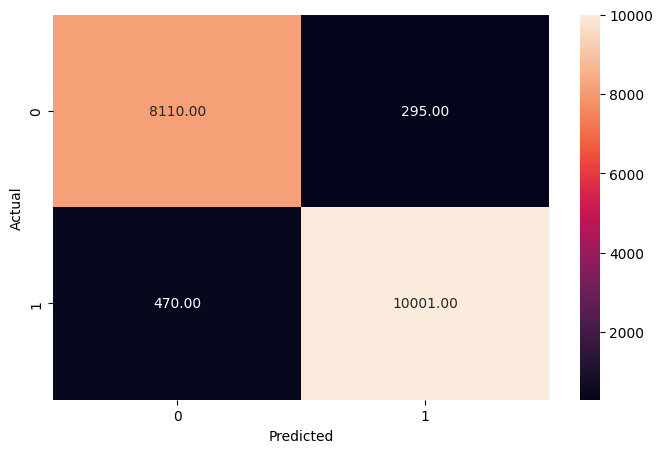

,Model,Precision,Recall,Accuracy
0,DecisionTree,92.61,92.57,92.68
1,RandomForest,95.26,95.40,95.38
2,RandomForest_GridSearchCV,95.28,95.40,95.39
3,XGBoost,95.38,95.57,95.51
4,XGBoost_pre-params,95.78,95.94,95.89
5,XGBoost_Tuned,95.83,96.00,95.95


In [88]:
# Evaluate the best model
print("XGBoost Classifier (Tuned):")
metrics_score(y_test, y_pred_best_xgb)
df_perf_best_xgb = model_performance_classification('XGBoost_Tuned', best_xgb_model, X_test, y_test)

# Register the tuned model's scores
scores_df = add_score(scores_df, df_perf_best_xgb)
scores_df



In [89]:
# Show best parameters for XGBoost after tuning
best_xgb_params
#show_important_features(best_xgb_model, X_test, 0.01)


{'n_estimators': 450,
 'max_depth': 13,
 'learning_rate': 0.04277963221626932,
 'subsample': 0.8803735305381981,
 'colsample_bytree': 0.616788411981516,
 'gamma': 0.0176544931344792,
 'lambda': 0.005017689503748073,
 'alpha': 0.04259493026313972}

### **Model-4: CatBoost model**

CatBoost Classifier:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      8405
           1       0.97      0.95      0.96     10471

    accuracy                           0.95     18876
   macro avg       0.95      0.95      0.95     18876
weighted avg       0.95      0.95      0.95     18876



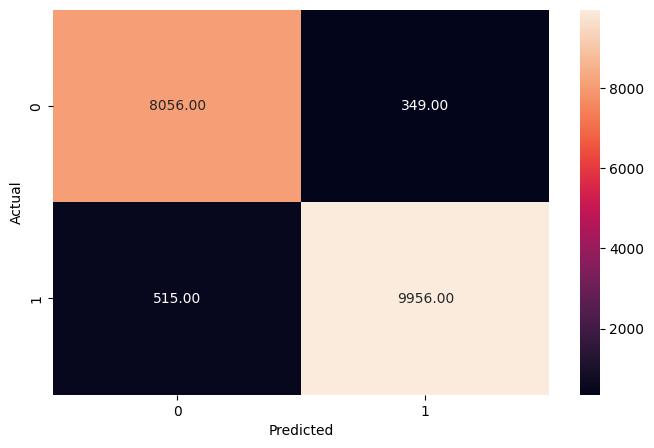

      Model  Precision  Recall  Accuracy
0  CatBoost       95.3   95.46     95.42


,Model,Precision,Recall,Accuracy
0,DecisionTree,92.61,92.57,92.68
1,RandomForest,95.26,95.40,95.38
2,RandomForest_GridSearchCV,95.28,95.40,95.39
3,XGBoost,95.38,95.57,95.51
4,XGBoost_pre-params,95.78,95.94,95.89
5,XGBoost_Tuned,95.83,96.00,95.95
6,CatBoost,95.30,95.46,95.42


In [90]:

# @title Create CatBoost model with default parameters

catboost_model = CatBoostClassifier(auto_class_weights="Balanced", task_type="GPU", random_seed=42, verbose=0)

# Fit the model to the training data
catboost_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_catboost = catboost_model.predict(X_test)

# Evaluate the model
print("CatBoost Classifier:")
metrics_score(y_test, y_pred_catboost)
df_perf_catboost = model_performance_classification('CatBoost', catboost_model, X_test, y_test)
print(df_perf_catboost)

# Register the model's scores
scores_df = add_score(scores_df, df_perf_catboost)
scores_df



CatBoost Pre-tuned Classifier:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      8405
           1       0.97      0.95      0.96     10471

    accuracy                           0.96     18876
   macro avg       0.96      0.96      0.96     18876
weighted avg       0.96      0.96      0.96     18876



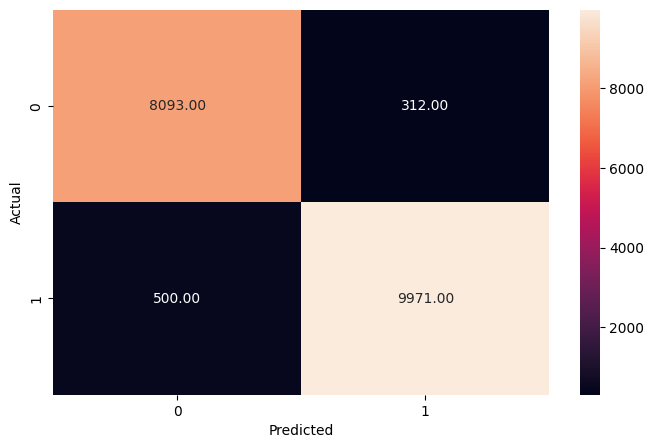

                Model  Precision  Recall  Accuracy
0  CatBoost_Pre-tuned      95.57   95.76      95.7


,Model,Precision,Recall,Accuracy
0,DecisionTree,92.61,92.57,92.68
1,RandomForest,95.26,95.40,95.38
2,RandomForest_GridSearchCV,95.28,95.40,95.39
3,XGBoost,95.38,95.57,95.51
4,XGBoost_pre-params,95.78,95.94,95.89
5,XGBoost_Tuned,95.83,96.00,95.95
6,CatBoost,95.30,95.46,95.42
7,CatBoost_Pre-tuned,95.57,95.76,95.70


In [91]:
# @title Create CatBoost model with pre-trained parameters
params = {'iterations': 575,
          'learning_rate': 0.05047947481946418,
          'depth': 10,
          'l2_leaf_reg': 6.356242656681124,
          'border_count': 222} # score 95.72

params = {'iterations': 575,
          'learning_rate': 0.04945407418149301,
          'depth': 9,
          'l2_leaf_reg': 4.6334292445712375,
          'border_count': 35} # score 95.75

params = {'iterations': 675,
          'learning_rate': 0.0717669759042332,
          'depth': 8,
          'l2_leaf_reg': 8.8839636719988,
          'border_count': 129} # score 95.76

catboost_params_model = CatBoostClassifier(**params, auto_class_weights="Balanced", task_type="GPU", random_seed=42, verbose=0)

# Fit the model to the training data
catboost_params_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_catboost = catboost_params_model.predict(X_test)

# Evaluate the model
print("CatBoost Pre-tuned Classifier:")
metrics_score(y_test, y_pred_catboost)
df_perf_catboost = model_performance_classification('CatBoost_Pre-tuned', catboost_params_model, X_test, y_test)
print(df_perf_catboost)

# Register the model's scores
scores_df = add_score(scores_df, df_perf_catboost)
scores_df

In [92]:
# @title Create CatBoost model with hyper-parameters optimization
def objective(trial):
    # Define the hyperparameter search space
    iterations = trial.suggest_int("iterations", 500, 700, step=25) # changed 400-800 to 500-700
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True) # changed 1e-3 - 0.3 log to 0.01-0.2
    depth = trial.suggest_int("depth", 8, 11) # changed 6-10 to 8-11
    l2_leaf_reg = trial.suggest_float("l2_leaf_reg", 4, 12) # changed 2-12 to 4-12
    border_count = trial.suggest_int("border_count", 32, 255)

    # Create the CatBoost model with the suggested hyperparameters
    catboost_model = CatBoostClassifier(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=depth,
        l2_leaf_reg=l2_leaf_reg,
        border_count=border_count,
        random_seed=42,
        verbose=0,
        auto_class_weights="Balanced",
        task_type="GPU",  # Enables GPU training
        devices="0",
        loss_function='Logloss'
    )

    # Fit the model to the training data
    catboost_model.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = catboost_model.predict(X_test)

    # Evaluate the model using accuracy
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy

# Create an Optuna study
study = optuna.create_study(direction="maximize")

# Optimize the objective function
study.optimize(objective, n_trials=100)  # You can adjust the number of trials

# Get the best hyperparameters
best_cat_params = study.best_params

# Create a CatBoost model with the best hyperparameters
best_catboost_model = CatBoostClassifier(**best_cat_params,
                                        auto_class_weights="Balanced",
                                        loss_function='Logloss',
                                        task_type="GPU", devices="0",
                                        random_seed=42, verbose=0)

# Fit the best model to the training data
best_catboost_model.fit(X_train, y_train)

# Make predictions on the test data using the best model
y_pred_best_catboost = best_catboost_model.predict(X_test)


[I 2025-03-20 13:32:25,026] A new study created in memory with name: no-name-0876f25a-c6ea-4b64-8037-41d1312b2444
[I 2025-03-20 13:32:34,727] Trial 0 finished with value: 0.9491417673235855 and parameters: {'iterations': 550, 'learning_rate': 0.010472406774044075, 'depth': 9, 'l2_leaf_reg': 7.287890250748525, 'border_count': 254}. Best is trial 0 with value: 0.9491417673235855.
[I 2025-03-20 13:32:48,841] Trial 1 finished with value: 0.9543865225683408 and parameters: {'iterations': 600, 'learning_rate': 0.015034171297923594, 'depth': 10, 'l2_leaf_reg': 4.014158992476926, 'border_count': 149}. Best is trial 1 with value: 0.9543865225683408.
[I 2025-03-20 13:32:55,900] Trial 2 finished with value: 0.9559228650137741 and parameters: {'iterations': 550, 'learning_rate': 0.04962074416135251, 'depth': 9, 'l2_leaf_reg': 6.008136333033383, 'border_count': 84}. Best is trial 2 with value: 0.9559228650137741.
[I 2025-03-20 13:33:09,014] Trial 3 finished with value: 0.9551811824539097 and parame

In [93]:
best_cat_params

{'iterations': 600,
 'learning_rate': 0.06930058333638392,
 'depth': 11,
 'l2_leaf_reg': 11.51001354470333,
 'border_count': 133}

In [94]:
# Show best and worst optuna results
show_octuna_trials(study)


Top 10 Results (Highest to Lowest):
Rank 1: Value: 0.9571943208306845, Parameters: {'iterations': 600, 'learning_rate': 0.06930058333638392, 'depth': 11, 'l2_leaf_reg': 11.51001354470333, 'border_count': 133}
Rank 2: Value: 0.9571413435049798, Parameters: {'iterations': 650, 'learning_rate': 0.08982403224336616, 'depth': 11, 'l2_leaf_reg': 9.68789120175422, 'border_count': 106}
Rank 3: Value: 0.9571413435049798, Parameters: {'iterations': 700, 'learning_rate': 0.1065382806605915, 'depth': 11, 'l2_leaf_reg': 11.170255393457955, 'border_count': 106}
Rank 4: Value: 0.9569824115278661, Parameters: {'iterations': 600, 'learning_rate': 0.06590178370042477, 'depth': 11, 'l2_leaf_reg': 11.388730875261636, 'border_count': 101}
Rank 5: Value: 0.9569824115278661, Parameters: {'iterations': 625, 'learning_rate': 0.06334312190714447, 'depth': 11, 'l2_leaf_reg': 11.361566946060172, 'border_count': 115}
Rank 6: Value: 0.9568764568764568, Parameters: {'iterations': 625, 'learning_rate': 0.098164561359

In [95]:
# # Optimizing CatBoost using grid search
# # Define CatBoost classifier
# cat_model = CatBoostClassifier(task_type="GPU", verbose=0, random_seed=42)

# # Define parameter grid
# param_grid = {
#     "iterations": [500, 1000],  # Number of boosting rounds
#     "learning_rate": [0.01, 0.05, 0.1],  # Learning rate
#     "depth": [4, 6, 8],  # Tree depth
#     "l2_leaf_reg": [1, 3, 5],  # Regularization
#     "border_count": [32, 64, 128, 255],  # Binning splits
#     "bagging_temperature": [0, 1, 5],  # Bagging randomness
#     "auto_class_weights": ["Balanced"],  # Class balancing
# }

# # Perform Grid Search using CatBoost's built-in method
# best_catboost_model = cat_model.randomized_search(param_grid, X=X_train, y=y_train, cv=5, stratified=True, refit=True)

# # Print the best parameters
# best_catboost_params = best_catboost_model["params"]
# print("Best Parameters:", best_catboost_params)


# # Make predictions on the test data using the best model
# y_pred_best_catboost = cat_model.predict(X_test)

CatBoost Classifier (Tuned):
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      8405
           1       0.97      0.95      0.96     10471

    accuracy                           0.96     18876
   macro avg       0.96      0.96      0.96     18876
weighted avg       0.96      0.96      0.96     18876



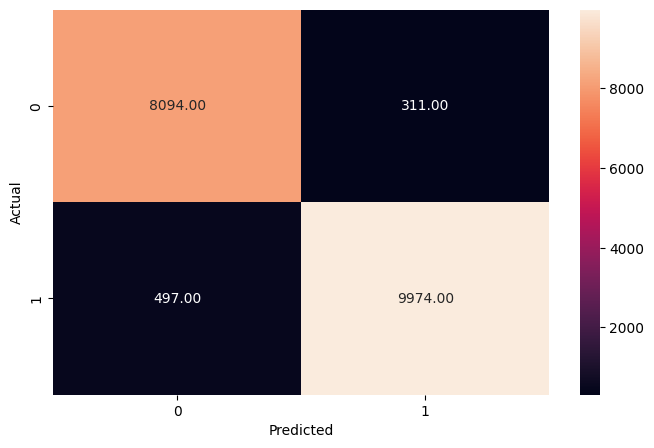

,Model,Precision,Recall,Accuracy
0,DecisionTree,92.61,92.57,92.68
1,RandomForest,95.26,95.40,95.38
2,RandomForest_GridSearchCV,95.28,95.40,95.39
3,XGBoost,95.38,95.57,95.51
4,XGBoost_pre-params,95.78,95.94,95.89
5,XGBoost_Tuned,95.83,96.00,95.95
6,CatBoost,95.30,95.46,95.42
7,CatBoost_Pre-tuned,95.57,95.76,95.70
8,CatBoost_Tuned,95.60,95.78,95.72


In [96]:
# Evaluate the best model
print("CatBoost Classifier (Tuned):")
metrics_score(y_test, y_pred_best_catboost)
df_perf_best_catboost = model_performance_classification('CatBoost_Tuned', best_catboost_model, X_test, y_test)

# Register the tuned model's scores
scores_df = add_score(scores_df, df_perf_best_catboost)
scores_df

### **Ensemble Model: Combine RandomForest, XGBoost, CatBoost**

In [97]:
# @title Create Ensemble Model

from sklearn.metrics import log_loss  # Or any other evaluation metric

# Get probability predictions for each model
xgb_probs = best_xgb_model.predict_proba(X_test)
cat_probs = best_catboost_model.predict_proba(X_test)
rf_probs = best_rf_model.predict_proba(X_test)


# Define the objective function for Optuna
def objective(trial):
    # Sample weights for each model from the search space
    w_xgb = trial.suggest_int("w_xgb", 5, 10)  # Weight for XGBoost
    w_cat = trial.suggest_int("w_cat", 2, 10)  # Weight for CatBoost
    w_rf = trial.suggest_int("w_rf", 0, 6)  # Weight for RandomForest

    # w_xgb = trial.suggest_uniform("w_xgb", 0, 1)  # Weight for XGBoost
    # w_cat = trial.suggest_uniform("w_cat", 0, 1)  # Weight for CatBoost
    # w_rf = trial.suggest_uniform("w_rf", 0, 1)  # Weight for RandomForest

    # Ensure the weights sum to 1
    total_weight = w_xgb + w_cat + w_rf

    if total_weight == 0:
        return 0  # Avoid division by zero

    w_xgb /= total_weight
    w_cat /= total_weight
    w_rf /= total_weight

    # Weighted averaging of probabilities
    final_probs = (w_xgb * xgb_probs + w_cat * cat_probs + w_rf * rf_probs)
    y_pred = np.argmax(final_probs, axis=1)

    accuracy = accuracy_score(y_test, y_pred)

    return accuracy

# Create and run Optuna study
study = optuna.create_study(direction="maximize")  # Minimize log loss
study.optimize(objective, n_trials=100)

# Best trial results
print(f"Best Trial: {study.best_trial.params}")

[I 2025-03-20 14:04:48,983] A new study created in memory with name: no-name-3e85f5cd-e143-4cd1-9b09-6086b3b630b3
[I 2025-03-20 14:04:48,989] Trial 0 finished with value: 0.9578300487391397 and parameters: {'w_xgb': 8, 'w_cat': 7, 'w_rf': 1}. Best is trial 0 with value: 0.9578300487391397.
[I 2025-03-20 14:04:48,994] Trial 1 finished with value: 0.9586776859504132 and parameters: {'w_xgb': 10, 'w_cat': 2, 'w_rf': 5}. Best is trial 1 with value: 0.9586776859504132.
[I 2025-03-20 14:04:48,998] Trial 2 finished with value: 0.9576711167620259 and parameters: {'w_xgb': 9, 'w_cat': 6, 'w_rf': 5}. Best is trial 1 with value: 0.9586776859504132.
[I 2025-03-20 14:04:49,002] Trial 3 finished with value: 0.9582538673447765 and parameters: {'w_xgb': 8, 'w_cat': 4, 'w_rf': 2}. Best is trial 1 with value: 0.9586776859504132.
[I 2025-03-20 14:04:49,007] Trial 4 finished with value: 0.957777071413435 and parameters: {'w_xgb': 8, 'w_cat': 3, 'w_rf': 6}. Best is trial 1 with value: 0.9586776859504132.
[

Best Trial: {'w_xgb': 8, 'w_cat': 2, 'w_rf': 0}


In [98]:
show_octuna_trials(study)

Top 10 Results (Highest to Lowest):
Rank 1: Value: 0.9593134138588684, Parameters: {'w_xgb': 8, 'w_cat': 2, 'w_rf': 0}
Rank 2: Value: 0.9593134138588684, Parameters: {'w_xgb': 10, 'w_cat': 2, 'w_rf': 0}
Rank 3: Value: 0.9593134138588684, Parameters: {'w_xgb': 8, 'w_cat': 2, 'w_rf': 0}
Rank 4: Value: 0.9593134138588684, Parameters: {'w_xgb': 8, 'w_cat': 2, 'w_rf': 0}
Rank 5: Value: 0.9593134138588684, Parameters: {'w_xgb': 8, 'w_cat': 2, 'w_rf': 0}
Rank 6: Value: 0.9593134138588684, Parameters: {'w_xgb': 8, 'w_cat': 2, 'w_rf': 0}
Rank 7: Value: 0.9593134138588684, Parameters: {'w_xgb': 8, 'w_cat': 2, 'w_rf': 0}
Rank 8: Value: 0.9593134138588684, Parameters: {'w_xgb': 8, 'w_cat': 2, 'w_rf': 0}
Rank 9: Value: 0.9593134138588684, Parameters: {'w_xgb': 8, 'w_cat': 2, 'w_rf': 0}
Rank 10: Value: 0.9593134138588684, Parameters: {'w_xgb': 8, 'w_cat': 2, 'w_rf': 0}
----------
Worst 10 Results (Lowest to Highest):
Rank 1: Value: 0.9578300487391397, Parameters: {'w_xgb': 6, 'w_cat': 4, 'w_rf': 4}


In [99]:
# Function that gets X as input and 3 weights w_rf, w_xgb, w_cat and return the y prediction of the ensemble of rf, xgb, cat

import numpy as np
def ensemble_predict(X, w_rf, w_xgb, w_cat):
    """
    Predicts the target variable using an ensemble of RandomForest, XGBoost, and CatBoost models.

    Args:
        X: The input features.
        w_rf: Weight for RandomForest model.
        w_xgb: Weight for XGBoost model.
        w_cat: Weight for CatBoost model.

    Returns:
        y_pred: The predicted target variable.
    """
    # Assuming best_rf_model, best_xgb_model, and best_catboost_model are already defined
    # and trained from the preceding code.  Replace with your actual model variables.
    xgb_probs = best_xgb_model.predict_proba(X)

    if w_cat > 0:
      cat_probs = best_catboost_model.predict_proba(X)
    else:
      cat_probs = np.zeros_like(xgb_probs)

    if w_rf > 0:
      rf_probs = best_rf_model.predict_proba(X)
    else:
      rf_probs = np.zeros_like(xgb_probs)

    total_weight = w_rf + w_xgb + w_cat
    if total_weight == 0:
        return 0 # Handle the edge case where all weights are zero.  Could return a default prediction or raise an error.

    w_xgb /= total_weight
    w_cat /= total_weight
    w_rf /= total_weight

    final_probs = (w_xgb * xgb_probs + w_cat * cat_probs + w_rf * rf_probs)
    y_pred = np.argmax(final_probs, axis=1)
    return y_pred


weights for xgb, cat and rf are: 0.8 0.2 0.0
Ensemble Model:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      8405
           1       0.97      0.95      0.96     10471

    accuracy                           0.96     18876
   macro avg       0.96      0.96      0.96     18876
weighted avg       0.96      0.96      0.96     18876



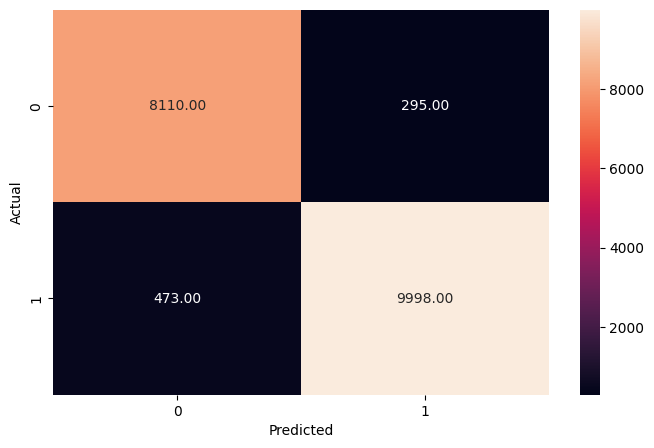

      Model  Precision  Recall  Accuracy
0  Ensemble      95.83    96.0     95.95


,Model,Precision,Recall,Accuracy
0,DecisionTree,92.61,92.57,92.68
1,RandomForest,95.26,95.40,95.38
2,RandomForest_GridSearchCV,95.28,95.40,95.39
3,XGBoost,95.38,95.57,95.51
4,XGBoost_pre-params,95.78,95.94,95.89
5,XGBoost_Tuned,95.83,96.00,95.95
6,CatBoost,95.30,95.46,95.42
7,CatBoost_Pre-tuned,95.57,95.76,95.70
8,CatBoost_Tuned,95.60,95.78,95.72
9,Ensemble,95.83,96.00,95.95


In [100]:
# Make ensemble prediction based on weighted combination of models

w_xgb = study.best_trial.params['w_xgb']
w_cat = study.best_trial.params['w_cat']
w_rf = study.best_trial.params['w_rf']
# Ensure the weights sum to 1
total_weight = w_xgb + w_cat + w_rf
w_xgb = round(w_xgb /total_weight,3)
w_cat = round(w_cat /total_weight,3)
w_rf  = round(w_rf /total_weight,3)

# w_rf = 0.20
# w_xgb = 0.50
# w_cat = 0.30
print ('weights for xgb, cat and rf are:',w_xgb,w_cat,w_rf)

y_pred_ensemble = ensemble_predict(X_test, w_rf, w_xgb, w_cat)

# Evaluate the ensemble model
print("Ensemble Model:")
metrics_score(y_test, y_pred_ensemble)
df_perf_ensemble = model_performance_classification('Ensemble', best_xgb_model, X_test, y_test)
print(df_perf_ensemble)

# Register the model's scores
scores_df = add_score(scores_df, df_perf_ensemble)
scores_df



## **Train on Full data for submission**

In [101]:
# train xgb with best_xgb_params on full Merged_train_df
scale_pos_weight = sum(y == 0) / sum(y == 1)

best_xgb_model = XGBClassifier(**best_xgb_params,
                               scale_pos_weight=scale_pos_weight,
                               device='cuda',
                               random_state=42, eval_metric='logloss')
best_xgb_model.fit(X, y)

XGBClassifier(alpha=0.04259493026313972, base_score=None, booster=None,
              callbacks=None, colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.616788411981516, device='cuda',
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None,
              gamma=0.0176544931344792, grow_policy=None, importance_type=None,
              interaction_constraints=None, lambda=0.005017689503748073,
              learning_rate=0.04277963221626932, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=13, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=450, n_jobs=None, ...)

In [102]:
# Train cat with best_cat_params on full Merged_train_df
best_cat_model = CatBoostClassifier(**best_cat_params,
                                    auto_class_weights="Balanced",
                                    loss_function='Logloss',
                                    task_type="GPU", devices="0",
                                    random_seed=42, verbose=0)
best_cat_model.fit(X, y)


In [103]:
# Make predicition on Merged_test_df

print ('weights for xgb, cat and rf are:',w_xgb,w_cat,w_rf)

y_pred_ensemble = ensemble_predict(Merged_test_df, w_rf, w_xgb, w_cat)

weights for xgb, cat and rf are: 0.8 0.2 0.0


In [104]:
# create submission file
submission = pd.DataFrame({'ID': Survey_test_df['ID'], 'Overall_Experience': y_pred_ensemble})
submission.to_csv('submission8.csv', index=False)

In [105]:
# Submit on prediction of xgboost only
y_pred_xgb = best_xgb_model.predict(Merged_test_df)

submission = pd.DataFrame({'ID': Survey_test_df['ID'], 'Overall_Experience': y_pred_xgb})
submission.to_csv('submission9.csv', index=False)

### Preparing data for TabNet - Normalize numerical values

In [107]:
# prompt: normalize X_train and X_test

from sklearn.preprocessing import StandardScaler

# Assuming X_train and X_test are your training and testing data
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [109]:
#!pip install pytorch_tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 33.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [115]:
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

In [119]:
# Initialize and train TabNet
# Check if CUDA is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

params = {
    "n_d": 16,
    "n_a": 16,
   # "n_steps": [3],
   # "gamma": [1.3, 1.5, 2.0],
   # "lambda_sparse": [0.0001, 0.001, 0.01],
   # "learning_rate": [0.005, 0.02, 0.05]
}
tabnet = TabNetClassifier(**params, device_name=device)
tabnet.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          eval_metric=['balanced_accuracy'],
          max_epochs=150, patience=10)

# Predictions
y_pred_tabnet = tabnet.predict(X_train)

Using device: cuda
epoch 0  | loss: 0.42257 | val_0_balanced_accuracy: 0.87971 |  0:00:06s
epoch 1  | loss: 0.25614 | val_0_balanced_accuracy: 0.90377 |  0:00:10s
epoch 2  | loss: 0.21493 | val_0_balanced_accuracy: 0.9158  |  0:00:14s
epoch 3  | loss: 0.18854 | val_0_balanced_accuracy: 0.92575 |  0:00:17s
epoch 4  | loss: 0.16408 | val_0_balanced_accuracy: 0.93334 |  0:00:22s
epoch 5  | loss: 0.15718 | val_0_balanced_accuracy: 0.94082 |  0:00:26s
epoch 6  | loss: 0.14372 | val_0_balanced_accuracy: 0.9447  |  0:00:29s
epoch 7  | loss: 0.13804 | val_0_balanced_accuracy: 0.94442 |  0:00:34s
epoch 8  | loss: 0.13221 | val_0_balanced_accuracy: 0.94868 |  0:00:37s
epoch 9  | loss: 0.12708 | val_0_balanced_accuracy: 0.94909 |  0:00:41s
epoch 10 | loss: 0.12275 | val_0_balanced_accuracy: 0.94761 |  0:00:45s
epoch 11 | loss: 0.12095 | val_0_balanced_accuracy: 0.94819 |  0:00:49s
epoch 12 | loss: 0.12047 | val_0_balanced_accuracy: 0.95071 |  0:00:53s
epoch 13 | loss: 0.11811 | val_0_balanced_acc

Tabnet Classifier:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      8405
           1       0.97      0.95      0.96     10471

    accuracy                           0.96     18876
   macro avg       0.96      0.96      0.96     18876
weighted avg       0.96      0.96      0.96     18876



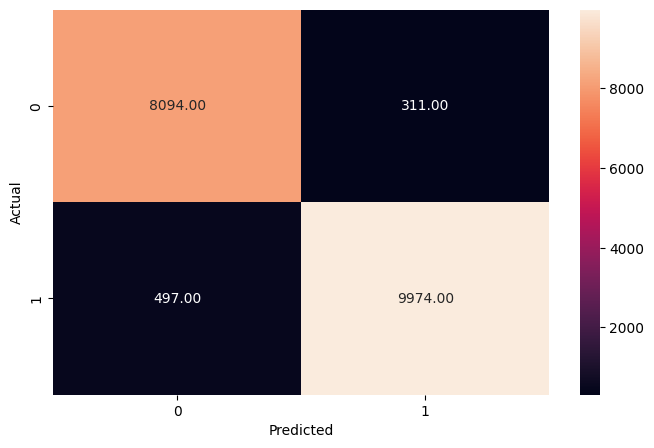

,Model,Precision,Recall,Accuracy
0,DecisionTree,92.61,92.57,92.68
1,RandomForest,95.26,95.40,95.38
2,RandomForest_GridSearchCV,95.28,95.40,95.39
3,XGBoost,95.38,95.57,95.51
4,XGBoost_pre-params,95.78,95.94,95.89
5,XGBoost_Tuned,95.83,96.00,95.95
6,CatBoost,95.30,95.46,95.42
7,CatBoost_Pre-tuned,95.57,95.76,95.70
8,CatBoost_Tuned,95.60,95.78,95.72
9,Ensemble,95.83,96.00,95.95


In [120]:
# Evaluate the best model
print("Tabnet Classifier:")
metrics_score(y_test, y_pred_tabnet)
df_perf_tabnet = model_performance_classification('TabNet', tabnet, X_test, y_test)

# Register the tuned model's scores
scores_df = add_score(scores_df, df_perf_tabnet)
scores_df

In [122]:
# Optimize parameters for Tabnet

def objective(trial):
    params = {
        "n_d": trial.suggest_int("n_d", 8, 32, step=8),
        "n_a": trial.suggest_int("n_a", 8, 32, step=8),
        "n_steps": trial.suggest_int("n_steps", 3, 10),
        "gamma": trial.suggest_float("gamma", 1.0, 2.5),
        "lambda_sparse": trial.suggest_loguniform("lambda_sparse", 1e-5, 1e-2),
        #"learning_rate": trial.suggest_loguniform("learning_rate", 1e-3, 1e-1),
    }

    model = TabNetClassifier(**params, verbose=0)
    model.fit(X_train, y_train, max_epochs=50, patience=10, batch_size=1024)
    y_pred = model.predict(X_test)
    return accuracy_score(y_test, y_pred)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)
print("Best Params:", study.best_params)

[I 2025-03-20 15:43:21,262] A new study created in memory with name: no-name-8a8e6fd7-8016-4cf8-b1b5-1e90d139a791
[I 2025-03-20 15:49:04,699] Trial 0 finished with value: 0.9539097266369994 and parameters: {'n_d': 8, 'n_a': 32, 'n_steps': 7, 'gamma': 1.4133463064413276, 'lambda_sparse': 3.212283467779246e-05}. Best is trial 0 with value: 0.9539097266369994.
[I 2025-03-20 15:52:07,160] Trial 1 finished with value: 0.9545984318711591 and parameters: {'n_d': 16, 'n_a': 8, 'n_steps': 3, 'gamma': 1.4861392665362019, 'lambda_sparse': 5.608321176977296e-05}. Best is trial 1 with value: 0.9545984318711591.
[I 2025-03-20 15:55:49,270] Trial 2 finished with value: 0.9541216359398178 and parameters: {'n_d': 8, 'n_a': 24, 'n_steps': 4, 'gamma': 2.0865848373969325, 'lambda_sparse': 2.306919499773776e-05}. Best is trial 1 with value: 0.9545984318711591.
[I 2025-03-20 16:03:31,568] Trial 3 finished with value: 0.9525852934943844 and parameters: {'n_d': 24, 'n_a': 8, 'n_steps': 10, 'gamma': 1.20168285

Best Params: {'n_d': 24, 'n_a': 16, 'n_steps': 4, 'gamma': 2.4688498818113542, 'lambda_sparse': 2.0198101941380347e-05}


In [1]:
best_tabnet = TabNetClassifier(**study.best_params, verbose=0)
best_tabnet.fit(X_train, y_train, max_epochs=50, patience=10, batch_size=1024)

NameError: name 'TabNetClassifier' is not defined

In [ ]:
# Evaluate the best model
print("Tabnet Optimized Classifier:")
y_pred_best_tabnet = best_tabnet.predict(X_test)
metrics_score(y_test, y_pred_best_tabnet)
df_perf_tabnet = model_performance_classification('TabNet-optimize', best_tabnet, X_test, y_test)

# Register the tuned model's scores
scores_df = add_score(scores_df, df_perf_tabnet)
scores_df

Results on 3.15:</br>


```
#     Model	      Precision	Recall	Accuracy
0	DecisionTree	      92.92	92.89	92.99
1	RandomForest	      95.26	95.42	95.38
2	RandomForest_Tuned	95.35	95.48	95.45
3	XGBoost	           95.25	95.43	95.38
4	XGBoost_Tuned	     95.71	95.90	95.84
5	CatBoost	          95.61	95.77	95.73
6	CatBoost_Tuned	    95.72	95.88	95.84
7	Ensemble	          95.71	95.90	95.84

Fiting CatBoost with eval
0	DecisionTree	      92.92	92.89	92.99
1	RandomForest	      95.26	95.42	95.38
2	RandomForest_Tuned	95.37	95.50	95.48
3	XGBoost	           95.25	95.43	95.38
4	XGBoost_Tuned	     95.62	95.78	95.74
5	CatBoost	          95.61	95.77	95.73
6	CatBoost_Tuned	    95.63	95.79	95.75
7	Ensemble	          95.62	95.78	95.74

0	DecisionTree	      92.92	92.89	92.99
1	RandomForest	      95.26	95.42	95.38
2	RandomForest_Tuned	95.35	95.48	95.46
3	XGBoost	           95.25	95.43	95.38
4	XGBoost_Tuned	     95.63	95.75	95.73
5	CatBoost	          95.25	95.41	95.37
6	CatBoost_Tuned_cv	 95.67	95.84	95.79
7	Ensemble	          95.63	95.75	95.73

log1p on depart and arrival delay
0	DecisionTree	      92.76	92.71	92.83
1	RandomForest	      95.21	95.36	95.33
2	RandomForest_Tuned	95.36	95.48	95.47
3	XGBoost	           95.25	95.43	95.38
4	XGBoost_Tuned	     95.69	95.86	95.81
5	CatBoost	          95.26	95.43	95.39
6	CatBoost_Tuned_cv	 95.60	95.75	95.71
7	Ensemble	          95.69	95.86	95.81

Updated optuna ranges + log1p
0	DecisionTree	      92.68	92.64	92.75
1	RandomForest	      95.26	95.38	95.36
2	RandomForest_Tuned	95.32	95.46	95.43
3	XGBoost	           95.25	95.43	95.38
4	XGBoost_Tuned	     95.73	95.89	95.85
5	CatBoost	          95.29	95.45	95.41
6	CatBoost_Tuned	    95.60	95.76	95.71
7	Ensemble	          95.73	95.89	95.85

Hackathon data
0	DecisionTree	      92.86	92.83	92.93
1	RandomForest	      95.19	95.33	95.31
2	RandomForest_Tuned	95.35	95.47	95.45
3	XGBoost	           95.25	95.43	95.38
4	XGBoost_pre-params	95.72	95.89	95.84
5	XGBoost_Tuned	     95.74	95.89	95.85
6	CatBoost	          95.28	95.44	95.40
7	CatBoost_Tuned	    95.68	95.86	95.80
8	Ensemble	          95.74	95.89	95.85

Second submission more tuned
0	DecisionTree	      92.86	92.83	92.93
1	RandomForest	      95.19	95.33	95.31
2	RF GridSearchCV	   95.34	95.47	95.45
3	XGBoost	           95.25	95.43	95.38
4	XGBoost_pre-params	95.74	95.89	95.85
5	XGBoost_Tuned	     95.85	96.01	95.96
6	CatBoost	          95.24	95.41	95.36
7	CatBoost_Pre-tuned	95.60	95.78	95.72
8	CatBoost_Tuned	    95.62	95.81	95.75
9	Ensemble	          95.85	96.01	95.96

Another fine tune
0	DecisionTree	      92.86	92.83	92.93
1	RandomForest	      95.34	95.47	95.45
2	RF_GridSearchCV	   95.34	95.47	95.45
3	XGBoost	           95.25	95.43	95.38
4	XGBoost_pre-params	95.66	95.82	95.78
5	XGBoost_Tuned	     95.82	95.99	95.94
6	CatBoost	          95.24	95.41	95.36
7	CatBoost_Pre-tuned	95.62	95.81	95.75
8	CatBoost_Tuned	    95.64	95.81	95.76
9	Ensemble	          95.82	95.99	95.94

capped on 0.99% outliers
0	DecisionTree	      92.76	92.71	92.82
1	RandomForest	      95.24	95.36	95.35
2	RF_GridSearchCV	   95.22	95.37	95.34
3	XGBoost	           95.38	95.57	95.51
4	XGBoost_pre-params	95.76	95.94	95.88
5	XGBoost_Tuned	     95.88	96.05	95.99
6	CatBoost	          95.27	95.43	95.39
7	CatBoost_Pre-tuned	95.61	95.78	95.73
8	CatBoost_Tuned	    95.68	95.86	95.80
9	Ensemble	          95.88	96.05	95.99

added log1p to travel_distance
0	DecisionTree	      92.73	92.68	92.80
1	RandomForest	      95.32	95.46	95.43
2	RF_GridSearchCV	   95.22	95.34	95.32
3	XGBoost	           95.38	95.57	95.51
4	XGBoost_pre-params	95.69	95.85	95.81
5	XGBoost_Tuned	     95.81	95.97	95.93
6	CatBoost	          95.27	95.44	95.39
7	CatBoost_Pre-tuned	95.52	95.70	95.64
8	CatBoost_Tuned	    95.63	95.81	95.76
9	Ensemble	          95.81	95.97	95.93

remove log1p from all
0	DecisionTree	      92.61	92.57	92.68
1	RandomForest	      95.26	95.40	95.38
2	RF_GridSearchCV	   95.28	95.40	95.39
3	XGBoost	           95.38	95.57	95.51
4	XGBoost_pre-params	95.78	95.94	95.89
5	XGBoost_Tuned	     95.83	96.00	95.95
6	CatBoost	          95.30	95.46	95.42
7	CatBoost_Pre-tuned	95.57	95.76	95.70
8	CatBoost_Tuned	    95.60	95.78	95.72
9	Ensemble	          95.83	96.00	95.95



